# Lab 8: High-Performance Big Data Analytics Using R


**Name:** Madhura Vilas Suroshe  |  **Roll No / ID:** 24102C2002  |  **Git repository:** https://github.com/Madhura1705/R_Programming/tree/main/24102C2002_R%20PROGRAMMING

**Runtime:** this notebook uses the **R kernel**. In Colab it opens as an R notebook automatically; if it does not, choose *Runtime → Change runtime type → R*. Then run **Runtime → Run all**.

**Workflow:** Problem Statement → Dataset → Data Preparation → Implementation → Analysis → Benchmarking → Visualizations → Observations → Critical Analysis → Conclusion

## 1. Problem Statement

The NYC Taxi and Limousine Commission (TLC) records millions of taxi trips containing pickup/drop-off zones, timestamps, passenger count, distance, fare, payment type and total amount. Processing such data with conventional approaches costs a lot of time and memory.

**Objective:** build a high-performance, scalable analytics solution in R that
- uses **data.table** for fast filtering, joining, grouping and aggregation;
- compares **functional** (`apply()`, `lapply()`, `purrr::map()`), **vectorized** and **data.table** implementations of the same operations;
- compares **sequential** and **parallel** (`foreach` + `doParallel`) execution of a heavy analysis on month-wise partitions;
- benchmarks everything with `microbenchmark`, `system.time()` and `bench`;
- extracts travel patterns (demand, revenue, routes, fares, payments), visualises them with `ggplot2`, and critically evaluates the approaches.

## 2. Dataset

**NYC TLC Yellow Taxi Trip Records** (official source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page), plus the **Taxi Zone Lookup Table** from the same page.

- **Subset used:** January to June 2023 (six monthly Parquet files, about 19 million trips), large enough to expose real performance differences.
- **Columns loaded** (only what the analysis needs, to save memory): pickup/drop-off time, passenger count, trip distance, pickup/drop-off location ID, payment type, fare, tip, tolls, total amount.
- **Zone lookup:** maps `LocationID` to Borough and Zone.

> If the files are slow to download or the RAM of your session is low, reduce the data by editing `MONTHS` in the configuration cell (for example `1:3`).

### 2.1 Install and load packages

In [ ]:
# Binary packages from Posit Package Manager install in seconds on Colab
os_info  <- readLines("/etc/os-release")
codename <- sub("VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", os_info, value = TRUE))
if (length(codename) == 0) codename <- "jammy"
options(repos = c(CRAN = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", codename)))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))

pkgs <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark",
          "purrr", "lubridate", "arrow", "scales", "bench", "leaflet")
missing_pkgs <- setdiff(pkgs, rownames(installed.packages()))
if (length(missing_pkgs)) install.packages(missing_pkgs, Ncpus = 2)
cat("All packages available:", all(pkgs %in% rownames(installed.packages())), "\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘lazyeval’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘iterators’, ‘assertthat’, ‘profmem’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’




All packages available: TRUE 


In [ ]:
suppressPackageStartupMessages({
  library(lubridate)       # loaded first so data.table functions take precedence
  library(data.table)
  library(ggplot2)
  library(foreach)
  library(doParallel)
  library(microbenchmark)
  library(purrr)
  library(scales)
})

Sys.setenv(TZ = "UTC")
options(repr.plot.width = 10, repr.plot.height = 5, scipen = 999)
theme_set(theme_minimal(base_size = 13))
set.seed(42)

cat("R version        :", R.version.string, "\n")
cat("Detected cores   :", detectCores(), "\n")
cat("data.table threads:", getDTthreads(), "\n")

R version        : R version 4.6.1 (2026-06-24) 
Detected cores   : 2 
data.table threads: 1 


In [ ]:
# ---------------- Configuration ----------------
MONTHS      <- sprintf("2023-%02d", 1:6)             # Jan - Jun 2023
START       <- ymd("2023-01-01", tz = "UTC")          # valid pickup window
END         <- ymd("2023-07-01", tz = "UTC")
N_SAMPLE    <- 1e6                                    # rows for group-by / join benchmarks
N_ROWWISE   <- 1e5                                    # rows for row-wise (apply) benchmark
SCALE_SIZES <- c(1e5, 5e5, 1e6, 2.5e6, 5e6)           # scalability experiment
BOOT_B      <- 200L                                   # bootstrap replicates (heavy task)
N_BOOT      <- 200000L                                # observations per bootstrap sample

In [ ]:
dir.create("nyc_taxi", showWarnings = FALSE)
options(timeout = 1200)
base_url <- "https://d37ci6vzurychx.cloudfront.net"
files    <- sprintf("yellow_tripdata_%s.parquet", MONTHS)

for (f in files) {
  dest <- file.path("nyc_taxi", f)
  if (!file.exists(dest) || file.size(dest) < 1e6) {
    cat("Downloading", f, "...\n")
    download.file(paste0(base_url, "/trip-data/", f), dest, mode = "wb", quiet = TRUE)
  }
}
zone_file <- file.path("nyc_taxi", "taxi_zone_lookup.csv")
if (!file.exists(zone_file))
  download.file(paste0(base_url, "/misc/taxi_zone_lookup.csv"), zone_file, mode = "wb", quiet = TRUE)

info <- file.info(list.files("nyc_taxi", full.names = TRUE))
print(data.frame(file = basename(rownames(info)), size_MB = round(info$size / 1024^2, 1)))

                             file size_MB
1            taxi_zone_lookup.csv     0.0
2 yellow_tripdata_2023-01.parquet    45.5
3 yellow_tripdata_2023-02.parquet    45.5
4 yellow_tripdata_2023-03.parquet    53.5
5 yellow_tripdata_2023-04.parquet    51.7
6 yellow_tripdata_2023-05.parquet    55.9
7 yellow_tripdata_2023-06.parquet    52.5


## 3. Task 1: Data Acquisition and Preparation (data.table)

### 3.1 Import the data
Only the needed columns are read from the Parquet files (column pruning), which reduces memory use from the start.

In [ ]:
keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
               "trip_distance", "PULocationID", "DOLocationID", "payment_type",
               "fare_amount", "tip_amount", "tolls_amount", "total_amount")

read_month <- function(f) {
  d <- arrow::read_parquet(file.path("nyc_taxi", f), col_select = keep_cols)
  setDT(d)
  d
}

t_load <- system.time({ dt <- rbindlist(lapply(files, read_month), use.names = TRUE) })
cat(sprintf("Loaded %s trips from %d files in %.1f s\n", comma(nrow(dt)), length(files), t_load[["elapsed"]]))

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(keep_cols)

  # Now:
  data %>% select(all_of(keep_cols))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Loaded 19,493,620 trips from 6 files in 6.2 s


### 3.2 Inspect structure, dimensions, data types and summary statistics

In [ ]:
cat("Rows:", comma(nrow(dt)), "| Columns:", ncol(dt), "\n")
mem_raw <- as.numeric(object.size(dt)) / 1024^2
cat(sprintf("Memory used by raw table: %.0f MB\n\n", mem_raw))
str(dt)

cat("\nMissing values per column:\n")
print(dt[, lapply(.SD, function(x) sum(is.na(x)))])

n_dup <- nrow(dt) - uniqueN(dt)
cat("\nExact duplicate rows:", comma(n_dup), "\n\n")
print(summary(dt))

Rows: 19,493,620 | Columns: 11 
Memory used by raw table: 1413 MB

Classes ‘data.table’ and 'data.frame':	19493620 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" ...
 $ passenger_count      : num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance        : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ PULocationID         : int  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID         : int  141 237 238 7 79 137 143 200 236 107 ...
 $ payment_type         : int  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount          : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount           : num  0 4 15 0 3.28 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount         : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x5cfdbcfd6240> 

Missing values per column:
   tpep_

### 3.3 Handle duplicate, missing, inconsistent and invalid records

Each rule is applied in turn and the number of rows it removes is logged, so the cleaning is fully transparent:

| Rule | Reason |
|---|---|
| Duplicates | exact repeated records |
| Missing values | key fields needed for analysis |
| Pickup outside Jan to Jun 2023 | the TLC files contain a few mis-dated records |
| Passengers not in 1 to 6 | zero or impossible counts |
| Distance not in (0, 100] miles | zero-distance or erroneous trips |
| Fare not in (0, 500] USD, negative tips/tolls, total <= 0 | refunds / data-entry errors |
| Duration not in (1 min, 6 h) | negative, tiny or runaway trip times |
| Speed > 80 mph | physically implausible in NYC |
| Zone IDs outside 1 to 265, payment type outside 1 to 6 | unknown or invalid codes |

In [ ]:
clean_log <- data.table(Step = "Raw data", Removed = 0L, Remaining = nrow(dt))
log_step  <- function(step, before, after)
  clean_log <<- rbind(clean_log, data.table(Step = step, Removed = before - after, Remaining = after))

# 1. exact duplicates
before <- nrow(dt); dt <- unique(dt); log_step("Exact duplicate rows", before, nrow(dt))

# 2. derived trip duration (minutes), needed by the validity rules
dt[, trip_minutes := (as.numeric(tpep_dropoff_datetime) - as.numeric(tpep_pickup_datetime)) / 60]

# 3. validity rules
rules <- list(
  "Missing values (key columns)"   = quote(!is.na(passenger_count) & !is.na(trip_distance) & !is.na(fare_amount) &
                                           !is.na(total_amount) & !is.na(PULocationID) & !is.na(DOLocationID) &
                                           !is.na(payment_type)),
  "Pickup outside Jan-Jun 2023"    = quote(tpep_pickup_datetime >= START & tpep_pickup_datetime < END),
  "Passengers not in 1-6"          = quote(passenger_count >= 1 & passenger_count <= 6),
  "Distance not in (0, 100] miles" = quote(trip_distance > 0 & trip_distance <= 100),
  "Fare not in (0, 500] USD"       = quote(fare_amount > 0 & fare_amount <= 500),
  "Negative tip/tolls or total<=0" = quote(tip_amount >= 0 & tolls_amount >= 0 & total_amount > 0),
  "Duration not in (1 min, 6 h)"   = quote(trip_minutes > 1 & trip_minutes <= 360),
  "Speed above 80 mph"             = quote(trip_distance / (trip_minutes / 60) <= 80),
  "Zone IDs outside 1-265"         = quote(PULocationID %in% 1:265 & DOLocationID %in% 1:265),
  "Payment type outside 1-6"       = quote(payment_type %in% 1:6)
)
for (nm in names(rules)) {
  before <- nrow(dt)
  dt <- dt[eval(rules[[nm]])]
  log_step(nm, before, nrow(dt))
}
invisible(gc())

clean_log[, Pct_removed := round(100 * Removed / clean_log$Remaining[1], 3)]
print(clean_log)
cat(sprintf("\nRetained %s of %s trips (%.2f%%)\n", comma(nrow(dt)), comma(clean_log$Remaining[1]),
            100 * nrow(dt) / clean_log$Remaining[1]))

                              Step Removed Remaining Pct_removed
                            <char>   <int>     <int>       <num>
 1:                       Raw data       0  19493620       0.000
 2:           Exact duplicate rows       0  19493620       0.000
 3:   Missing values (key columns)  528552  18965068       2.711
 4:    Pickup outside Jan-Jun 2023     101  18964967       0.001
 5:          Passengers not in 1-6  327861  18637106       1.682
 6: Distance not in (0, 100] miles  231569  18405537       1.188
 7:       Fare not in (0, 500] USD  154355  18251182       0.792
 8: Negative tip/tolls or total<=0       0  18251182       0.000
 9:   Duration not in (1 min, 6 h)   73193  18177989       0.375
10:             Speed above 80 mph     779  18177210       0.004
11:         Zone IDs outside 1-265       0  18177210       0.000
12:       Payment type outside 1-6       0  18177210       0.000

Retained 18,177,210 of 19,493,620 trips (93.25%)


### 3.4 Convert data types, extract temporal attributes and drop unneeded columns

In [ ]:
# Appropriate types: integers for counts/IDs, factor for payment type
dt[, `:=`(passenger_count = as.integer(passenger_count),
          PULocationID    = as.integer(PULocationID),
          DOLocationID    = as.integer(DOLocationID))]
dt[, payment_type := factor(payment_type, levels = 1:6,
      labels = c("Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided trip"))]

# Temporal attributes (data.table's native, very fast date-time functions)
setattr(dt$tpep_pickup_datetime, "tzone", "UTC")
dt[, `:=`(hour         = data.table::hour(tpep_pickup_datetime),
          day          = data.table::mday(tpep_pickup_datetime),
          dow          = data.table::wday(tpep_pickup_datetime),      # 1 = Sunday ... 7 = Saturday
          pickup_month = data.table::month(tpep_pickup_datetime),
          pickup_date  = as.IDate(tpep_pickup_datetime))]

# Remove raw timestamps no longer needed (memory)
dt[, c("tpep_pickup_datetime", "tpep_dropoff_datetime") := NULL]
invisible(gc())

mem_clean <- as.numeric(object.size(dt)) / 1024^2
cat(sprintf("Memory: raw table %.0f MB  ->  cleaned table %.0f MB (%s rows)\n", mem_raw, mem_clean, comma(nrow(dt))))
str(dt)

Memory: raw table 1413 MB  ->  cleaned table 1456 MB (18,177,210 rows)
Classes ‘data.table’ and 'data.frame':	18177210 obs. of  15 variables:
 $ passenger_count: int  1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance  : num  0.97 1.1 2.51 1.43 1.84 1.66 11.7 2.95 3.01 1.8 ...
 $ PULocationID   : int  161 43 48 107 161 239 142 164 141 234 ...
 $ DOLocationID   : int  141 237 238 79 137 143 200 236 107 68 ...
 $ payment_type   : Factor w/ 6 levels "Credit card",..: 2 1 1 1 1 1 1 1 2 1 ...
 $ fare_amount    : num  9.3 7.9 14.9 11.4 12.8 12.1 45.7 17.7 14.9 11.4 ...
 $ tip_amount     : num  0 4 15 3.28 10 ...
 $ tolls_amount   : num  0 0 0 0 0 0 3 0 0 0 ...
 $ total_amount   : num  14.3 16.9 34.9 19.7 27.8 ...
 $ trip_minutes   : num  8.43 6.32 12.75 10.83 12.3 ...
 $ hour           : int  0 0 0 0 0 0 0 0 0 0 ...
 $ day            : int  1 1 1 1 1 1 1 1 1 1 ...
 $ dow            : int  1 1 1 1 1 1 1 1 1 1 ...
 $ pickup_month   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ pickup_date    : IDate, format: "2023-

### 3.5 Import the Taxi Zone Lookup Table and join it with the trips (data.table update-join)

In [ ]:
zones <- fread(file.path("nyc_taxi", "taxi_zone_lookup.csv"))
zones[is.na(Borough) | Borough %in% c("N/A", ""), Borough := "Unknown"]
setkey(zones, LocationID)
cat("Zones:", nrow(zones), "| Boroughs:", paste(sort(unique(zones$Borough)), collapse = ", "), "\n")
print(head(zones))

# Update joins by reference: no copy of the 19M-row table is made
t_join <- system.time({
  dt[zones, on = .(PULocationID = LocationID), `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone)]
  dt[zones, on = .(DOLocationID = LocationID), `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone)]
  dt[, `:=`(PU_Borough = factor(PU_Borough), DO_Borough = factor(DO_Borough))]
})
cat(sprintf("\nJoined %s trips with zone information in %.2f s\n", comma(nrow(dt)), t_join[["elapsed"]]))
cat("Trips with unmatched pickup zone:", dt[is.na(PU_Zone), .N], "\n")
print(head(dt, 5))

Zones: 265 | Boroughs: Bronx, Brooklyn, EWR, Manhattan, Queens, Staten Island, Unknown 
Key: <LocationID>
   LocationID       Borough                    Zone service_zone
        <int>        <char>                  <char>       <char>
1:          1           EWR          Newark Airport          EWR
2:          2        Queens             Jamaica Bay    Boro Zone
3:          3         Bronx Allerton/Pelham Gardens    Boro Zone
4:          4     Manhattan           Alphabet City  Yellow Zone
5:          5 Staten Island           Arden Heights    Boro Zone
6:          6 Staten Island Arrochar/Fort Wadsworth    Boro Zone

Joined 18,177,210 trips with zone information in 7.46 s
Trips with unmatched pickup zone: 0 
   passenger_count trip_distance PULocationID DOLocationID payment_type
             <int>         <num>        <int>        <int>       <fctr>
1:               1          0.97          161          141         Cash
2:               1          1.10           43          237  Cred

## 4. Task 2: Transportation Data Analytics (data.table)

### 4.1 Trips by hour, day of week and month; average fare and revenue by period

In [ ]:
period_labels <- c("Overnight (00-05)", "Morning rush (06-09)", "Midday (10-15)",
                   "Evening rush (16-19)", "Night (20-23)")
dt[, period := factor(findInterval(hour, c(0, 6, 10, 16, 20)), levels = 1:5, labels = period_labels)]

hourly <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = hour]
hourly[, period := factor(findInterval(hour, c(0, 6, 10, 16, 20)), levels = 1:5, labels = period_labels)]

day_names <- c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")
dow_tbl <- dt[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = dow]
dow_tbl[, day_name := factor(day_names[dow], levels = c("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"))]

monthly <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_distance = mean(trip_distance),
                  revenue = sum(total_amount)), keyby = pickup_month]
monthly[, month_name := factor(month.abb[pickup_month], levels = month.abb[sort(unique(pickup_month))])]

periods <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_total = mean(total_amount),
                  revenue = sum(total_amount)), keyby = period]

cat("TRIPS AND FARE BY HOUR\n");   print(hourly[, .(hour, trips, avg_fare = round(avg_fare, 2), revenue = round(revenue))])
cat("\nBY DAY OF WEEK\n");         print(dow_tbl[order(day_name), .(day_name, trips, avg_fare = round(avg_fare, 2), revenue = round(revenue))])
cat("\nBY MONTH\n");               print(monthly[, .(month_name, trips, avg_fare = round(avg_fare, 2), avg_distance = round(avg_distance, 2), revenue = round(revenue))])
cat("\nBY TIME PERIOD\n");         print(periods[, .(period, trips, avg_fare = round(avg_fare, 2), avg_total = round(avg_total, 2), revenue = round(revenue))])

cat("\n--- Interpretation (computed from the results) ---\n")
cat(sprintf("* Demand peaks at %02d:00 (%s trips) and is lowest at %02d:00 (%s trips).\n",
            hourly[which.max(trips), hour], comma(hourly[which.max(trips), trips]),
            hourly[which.min(trips), hour], comma(hourly[which.min(trips), trips])))
cat(sprintf("* Highest average fare occurs at %02d:00 ($%.2f), lowest at %02d:00 ($%.2f): fares are driven by trip length, not only by demand.\n",
            hourly[which.max(avg_fare), hour], max(hourly$avg_fare), hourly[which.min(avg_fare), hour], min(hourly$avg_fare)))
cat(sprintf("* Busiest weekday: %s (%s trips); quietest: %s (%s trips).\n",
            dow_tbl[which.max(trips), day_name], comma(dow_tbl[which.max(trips), trips]),
            dow_tbl[which.min(trips), day_name], comma(dow_tbl[which.min(trips), trips])))
cat(sprintf("* Busiest month: %s (%s trips); highest revenue: %s ($%s).\n",
            monthly[which.max(trips), month_name], comma(monthly[which.max(trips), trips]),
            monthly[which.max(revenue), month_name], comma(round(monthly[which.max(revenue), revenue]))))
cat(sprintf("* Most lucrative period per trip: %s ($%.2f average total); highest total revenue: %s.\n",
            periods[which.max(avg_total), period], max(periods$avg_total), periods[which.max(revenue), period]))

TRIPS AND FARE BY HOUR
Key: <hour>
     hour   trips avg_fare  revenue
    <int>   <int>    <num>    <num>
 1:     0  505508    20.02 14753393
 2:     1  335583    18.29  9007901
 3:     2  219107    17.02  5521161
 4:     3  142870    17.96  3764745
 5:     4   90267    23.55  3010626
 6:     5   97593    27.51  3750771
 7:     6  244540    23.05  7807269
 8:     7  488215    19.23 13368627
 9:     8  679361    18.18 17774998
10:     9  774229    18.33 20465857
11:    10  845226    18.52 22518396
12:    11  919231    18.74 24697274
13:    12  995741    19.16 27272522
14:    13 1028937    19.90 29132213
15:    14 1107414    20.74 32574978
16:    15 1126315    20.57 32788780
17:    16 1130059    20.60 35204737
18:    17 1232609    19.27 36478669
19:    18 1299489    17.78 36157147
20:    19 1158953    17.90 32400133
21:    20 1027061    18.45 28430785
22:    21 1027075    18.75 28768991
23:    22  953519    19.66 27649923
24:    23  748308    20.87 22796330
     hour   trips avg_fare  r

### 4.2 Most frequent and highest-revenue routes; top pickup and drop-off zones
Routes are aggregated on the small integer IDs first and the zone names are attached afterwards to the (small) result, which is far cheaper than grouping 19M rows by strings.

In [ ]:
routes <- dt[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount),
                 avg_distance = mean(trip_distance)), by = .(PULocationID, DOLocationID)]
routes[zones, on = .(PULocationID = LocationID), `:=`(PU_Zone = i.Zone, PU_Borough = i.Borough)]
routes[zones, on = .(DOLocationID = LocationID), `:=`(DO_Zone = i.Zone)]
routes[, route := paste(PU_Zone, "to", DO_Zone)]
cat("Distinct pickup-dropoff routes:", comma(nrow(routes)), "\n")

top_routes_freq <- routes[order(-trips)][1:15]
top_routes_rev  <- routes[order(-revenue)][1:15]

cat("\nTOP 15 MOST FREQUENT ROUTES\n")
print(top_routes_freq[, .(route, trips, avg_fare = round(avg_fare, 2), avg_distance = round(avg_distance, 2), revenue = round(revenue))])
cat("\nTOP 15 HIGHEST-REVENUE ROUTES\n")
print(top_routes_rev[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2), avg_distance = round(avg_distance, 2))])

top_pu <- dt[, .(trips = .N, revenue = sum(total_amount)), by = PU_Zone][order(-trips)][1:10]
top_do <- dt[, .(trips = .N, revenue = sum(total_amount)), by = DO_Zone][order(-trips)][1:10]
cat("\nTOP 10 PICKUP ZONES\n");   print(top_pu)
cat("\nTOP 10 DROP-OFF ZONES\n"); print(top_do)

cat("\n--- Interpretation ---\n")
cat(sprintf("* The most frequent route is '%s' (%s trips, avg fare $%.2f).\n",
            top_routes_freq$route[1], comma(top_routes_freq$trips[1]), top_routes_freq$avg_fare[1]))
cat(sprintf("* The highest-revenue route is '%s' ($%s from %s trips): high-revenue routes tend to be long trips (avg %.1f miles) rather than the most frequent ones.\n",
            top_routes_rev$route[1], comma(round(top_routes_rev$revenue[1])), comma(top_routes_rev$trips[1]), top_routes_rev$avg_distance[1]))
cat(sprintf("* Overlap between top-15 frequent and top-15 revenue routes: %d routes.\n",
            length(intersect(top_routes_freq$route, top_routes_rev$route))))

Distinct pickup-dropoff routes: 35,721 

TOP 15 MOST FREQUENT ROUTES
                                             route  trips avg_fare avg_distance
                                            <char>  <int>    <num>        <num>
 1:                                     N/A to N/A 138636    19.93         3.64
 2: Upper East Side South to Upper East Side North 128520     8.87         1.08
 3: Upper East Side North to Upper East Side South 109270     9.45         1.06
 4: Upper East Side South to Upper East Side South  81847     7.30         0.68
 5: Upper East Side North to Upper East Side North  81037     6.71         0.66
 6:        Midtown Center to Upper East Side South  58740    10.01         1.11
 7:        Upper East Side South to Midtown Center  57306    10.16         1.08
 8:        Midtown Center to Upper East Side North  52020    14.05         1.98
 9:   Lincoln Square East to Upper West Side South  48545     8.16         1.02
10:   Upper West Side South to Lincoln Square East 

### 4.3 Relationship between trip distance and fare

In [ ]:
set.seed(1)
s <- dt[sample.int(.N, min(5e5, .N)), .(trip_distance, fare_amount)]
fit <- lm(fare_amount ~ trip_distance, data = s)
r_df <- cor(s$trip_distance, s$fare_amount)
print(summary(fit)$coefficients)

dist_labels <- c("<1", "1-2", "2-3", "3-5", "5-10", "10-20", "20+")
dist_bins <- dt[, .(trips = .N, avg_fare = mean(fare_amount),
                    fare_per_mile = sum(fare_amount) / sum(trip_distance)),
                keyby = .(dist_bin = cut(trip_distance, c(0, 1, 2, 3, 5, 10, 20, Inf),
                                         labels = dist_labels, right = FALSE))]
print(dist_bins[, .(dist_bin, trips, avg_fare = round(avg_fare, 2), fare_per_mile = round(fare_per_mile, 2))])

cat("\n--- Interpretation ---\n")
cat(sprintf("* Correlation between distance and fare: r = %.3f (R-squared = %.3f): distance explains most of the fare.\n", r_df, r_df^2))
cat(sprintf("* Linear model: fare = %.2f + %.2f x miles, i.e. about $%.2f flag-drop plus $%.2f per mile.\n",
            coef(fit)[1], coef(fit)[2], coef(fit)[1], coef(fit)[2]))
cat(sprintf("* Fare per mile is highest for the shortest trips (%s: $%.2f/mile) because the fixed starting charge dominates, and falls to $%.2f/mile for %s-mile trips.\n",
            dist_bins$dist_bin[1], dist_bins$fare_per_mile[1], dist_bins$fare_per_mile[nrow(dist_bins)], dist_bins$dist_bin[nrow(dist_bins)]))

              Estimate  Std. Error   t value Pr(>|t|)
(Intercept)   6.286213 0.008820525  712.6801        0
trip_distance 3.720540 0.001548608 2402.5061        0
Key: <dist_bin>
   dist_bin   trips avg_fare fare_per_mile
     <fctr>   <int>    <num>         <num>
1:       <1 3718560     7.41         10.64
2:      1-2 6142544    11.40          7.92
3:      2-3 3022758    16.20          6.70
4:      3-5 2139971    22.07          5.86
5:     5-10 1566023    34.29          4.74
6:    10-20 1384190    61.79          4.13
7:      20+  203164    88.44          3.74

--- Interpretation ---
* Correlation between distance and fare: r = 0.959 (R-squared = 0.920): distance explains most of the fare.
* Linear model: fare = 6.29 + 3.72 x miles, i.e. about $6.29 flag-drop plus $3.72 per mile.
* Fare per mile is highest for the shortest trips (<1: $10.64/mile) because the fixed starting charge dominates, and falls to $3.74/mile for 20+-mile trips.


### 4.4 Payment methods across boroughs

In [ ]:
pay_overall <- dt[, .(trips = .N), by = payment_type][, share := round(100 * trips / sum(trips), 2)][order(-trips)]
pay_borough <- dt[, .N, by = .(PU_Borough, payment_type)][, share := 100 * N / sum(N), by = PU_Borough]
tip_by_pay  <- dt[, .(avg_tip = round(mean(tip_amount), 2), tip_pct_of_fare = round(100 * sum(tip_amount) / sum(fare_amount), 1)),
                  by = payment_type][order(-avg_tip)]

cat("OVERALL PAYMENT SHARE\n");  print(pay_overall)
cat("\nPAYMENT SHARE (%) BY PICKUP BOROUGH\n")
print(dcast(pay_borough, PU_Borough ~ payment_type, value.var = "share", fill = 0)[, lapply(.SD, function(x) if (is.numeric(x)) round(x, 1) else x)])
cat("\nTIPS BY PAYMENT TYPE\n");  print(tip_by_pay)

cat("\n--- Interpretation ---\n")
cat(sprintf("* %s is the dominant payment method (%.1f%% of trips), followed by %s (%.1f%%).\n",
            pay_overall$payment_type[1], pay_overall$share[1], pay_overall$payment_type[2], pay_overall$share[2]))
cc <- pay_borough[payment_type == "Credit card"]
cat(sprintf("* Card usage is highest for pickups in %s (%.1f%%) and lowest in %s (%.1f%%).\n",
            cc[which.max(share), PU_Borough], max(cc$share), cc[which.min(share), PU_Borough], min(cc$share)))
cat("* Cash tips are not recorded in the TLC data, so the average tip for cash trips is (near) zero: tip analysis is only meaningful for card payments.\n")

OVERALL PAYMENT SHARE
   payment_type    trips share
         <fctr>    <int> <num>
1:  Credit card 14912256 82.04
2:         Cash  3105320 17.08
3:      Dispute   103249  0.57
4:    No charge    56385  0.31

PAYMENT SHARE (%) BY PICKUP BOROUGH
Key: <PU_Borough>
      PU_Borough Credit card  Cash No charge Dispute
          <fctr>       <num> <num>     <num>   <num>
1:         Bronx        83.4  15.6       0.4     0.6
2:      Brooklyn        80.3  18.4       0.5     0.8
3:           EWR        70.3  23.6       2.7     3.3
4:     Manhattan        82.5  16.6       0.3     0.5
5:        Queens        77.6  21.2       0.4     0.7
6: Staten Island        95.6   3.8       0.4     0.3
7:       Unknown        81.3  17.8       0.3     0.7

TIPS BY PAYMENT TYPE
   payment_type avg_tip tip_pct_of_fare
         <fctr>   <num>           <num>
1:  Credit card    4.32            22.4
2:      Dispute    0.03             0.1
3:    No charge    0.01             0.1
4:         Cash    0.00             0.

### 4.5 Additional patterns: speed by hour, airport trips, weekday vs weekend, tipping behaviour

In [ ]:
speed_hour <- dt[, .(avg_mph = sum(trip_distance) / (sum(trip_minutes) / 60)), keyby = hour]
tip_hour   <- dt[payment_type == "Credit card", .(tip_pct = 100 * sum(tip_amount) / sum(fare_amount)), keyby = hour]

airport_ids <- zones[grepl("Airport", Zone), LocationID]
airport <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_total = mean(total_amount),
                  avg_distance = mean(trip_distance), revenue = sum(total_amount)),
              keyby = .(airport_trip = PULocationID %in% airport_ids | DOLocationID %in% airport_ids)]
airport[, `:=`(airport_trip = ifelse(airport_trip, "Airport trip", "Non-airport trip"),
               revenue_share = round(100 * revenue / sum(revenue), 1))]

wk <- dt[, .(trips = .N, avg_fare = mean(fare_amount), avg_distance = mean(trip_distance)),
         keyby = .(day_type = ifelse(dow %in% c(1, 7), "Weekend", "Weekday"))]

print(speed_hour[, .(hour, avg_mph = round(avg_mph, 1))][c(1, 4, 8, 12, 17, 18, 22)])
print(airport)
print(wk)

cat("\n--- Interpretation ---\n")
cat(sprintf("* Traffic is slowest around %02d:00 (%.1f mph) and fastest around %02d:00 (%.1f mph): congestion visibly lowers speeds during the day.\n",
            speed_hour[which.min(avg_mph), hour], min(speed_hour$avg_mph), speed_hour[which.max(avg_mph), hour], max(speed_hour$avg_mph)))
a <- airport[airport_trip == "Airport trip"]; n <- airport[airport_trip == "Non-airport trip"]
cat(sprintf("* Airport trips are only %.1f%% of trips but %.1f%% of revenue; their average total ($%.2f) is %.1fx a normal trip ($%.2f).\n",
            100 * a$trips / sum(airport$trips), a$revenue_share, a$avg_total, a$avg_total / n$avg_total, n$avg_total))
cat(sprintf("* Credit-card tipping averages %.1f%% of the fare, with the highest tip percentage at %02d:00 (%.1f%%).\n",
            100 * sum(dt[payment_type == "Credit card", tip_amount]) / sum(dt[payment_type == "Credit card", fare_amount]),
            tip_hour[which.max(tip_pct), hour], max(tip_hour$tip_pct)))
cat(sprintf("* Weekday trips: %s (avg %.1f miles) vs weekend trips: %s (avg %.1f miles).\n",
            comma(wk[day_type == "Weekday", trips]), wk[day_type == "Weekday", avg_distance],
            comma(wk[day_type == "Weekend", trips]), wk[day_type == "Weekend", avg_distance]))

Key: <hour>
    hour avg_mph
   <int>   <num>
1:     0    17.3
2:     3    17.8
3:     7    15.1
4:    11    11.7
5:    16    11.6
6:    17    11.4
7:    21    15.4
       airport_trip    trips avg_fare avg_total avg_distance   revenue
             <char>    <int>    <num>     <num>        <num>     <num>
1: Non-airport trip 16204848 14.77712  22.45175     2.254556 363827153
2:     Airport trip  1972362 56.51973  77.20138    13.738381 152269072
   revenue_share
           <num>
1:          70.5
2:          29.5
Key: <day_type>
   day_type    trips avg_fare avg_distance
     <char>    <int>    <num>        <num>
1:  Weekday 13302152 19.32275     3.459728
2:  Weekend  4875058 19.26217     3.612258

--- Interpretation ---
* Traffic is slowest around 17:00 (11.4 mph) and fastest around 05:00 (24.7 mph): congestion visibly lowers speeds during the day.
* Airport trips are only 10.9% of trips but 29.5% of revenue; their average total ($77.20) is 3.4x a normal trip ($22.45).
* Credit-card tip

## 5. Task 3: Functional and Efficient R Programming

The same analytical operations are implemented in four styles and benchmarked on random samples of the cleaned data:

| Operation | Implementations compared |
|---|---|
| **A. Group aggregation** (mean fare per hour, 1M rows) | `aggregate()` (base R), `tapply()`, `lapply()` loop, `purrr::map_dbl()`, vectorized `rowsum()`, `data.table` |
| **B. Row-wise calculation** (fare per mile, 100k rows) | `apply()`, `lapply()`, `purrr::map2_dbl()`, vectorized division, `data.table :=` |
| **C. Join with zone table** (1M rows) | `merge()` (base R), `match()` lookup (vectorized), `data.table` join |

Slow row-wise approaches are run on a smaller sample (100k rows) because `apply()` on millions of rows would take minutes; this is itself a finding.

In [ ]:
set.seed(42)
take <- function(n) dt[sample.int(.N, n, replace = n > .N)]

sdt <- take(N_SAMPLE)[, .(hour, fare_amount, trip_distance, tip_amount, total_amount, PULocationID)]
sdf <- as.data.frame(sdt)                       # same data as a data.frame for base-R / functional code
hours <- 0:23
cat("Benchmark sample:", comma(nrow(sdt)), "rows\n")

Benchmark sample: 1,000,000 rows


### 5.1 Operation A: group aggregation (mean fare per hour)

In [ ]:

# --- Correctness check: all implementations must give the same answer ---

# 1. Base R: aggregate
r1 <- aggregate(
  fare_amount ~ hour,
  data = sdf,
  FUN = mean
)

# 2. Base R: tapply, ordered by hour
r2 <- as.numeric(
  tapply(sdf$fare_amount, sdf$hour, mean)[as.character(hours)]
)

# 3. Functional programming: lapply
r3 <- unlist(
  lapply(hours, function(h) {
    mean(sdf$fare_amount[sdf$hour == h])
  })
)

# 4. Functional programming: purrr map_dbl
r4 <- map_dbl(
  hours,
  ~ mean(sdf$fare_amount[sdf$hour == .x])
)

# 5. Vectorized aggregation: rowsum
rs_sum <- rowsum(sdf$fare_amount, sdf$hour)
rs_n <- rowsum(rep(1, nrow(sdf)), sdf$hour)

r5 <- as.numeric(
  rs_sum[as.character(hours), 1] /
    rs_n[as.character(hours), 1]
)

# 6. data.table aggregation
r6_df <- sdt[, .(m = mean(fare_amount)), keyby = hour]
r6 <- r6_df[match(hours, hour), m]

# Compare all implementations with aggregate
reference <- r1$fare_amount

results <- list(
  tapply = r2,
  lapply = r3,
  purrr_map = r4,
  rowsum = r5,
  data_table = r6
)

checks <- sapply(results, function(x) {
  isTRUE(all.equal(reference, x, tolerance = 1e-8))
})

cat("Correctness check:\n")
print(checks)
cat("\nAll six implementations agree:", all(checks), "\n\n")

# --- Benchmark performance ---
mb_group <- microbenchmark(
  base_aggregate = aggregate(
    fare_amount ~ hour, data = sdf, FUN = mean
  ),
  base_tapply = tapply(
    sdf$fare_amount, sdf$hour, mean
  ),
  lapply_loop = lapply(
    hours, function(h) {
      mean(sdf$fare_amount[sdf$hour == h])
    }
  ),
  purrr_map = map_dbl(
    hours, ~ mean(sdf$fare_amount[sdf$hour == .x])
  ),
  vectorized_rowsum = {
    rs <- rowsum(sdf$fare_amount, sdf$hour)
    rn <- rowsum(rep(1, nrow(sdf)), sdf$hour)
    as.numeric(
      rs[as.character(hours), 1] /
        rn[as.character(hours), 1]
    )
  },
  data_table = sdt[, .(m = mean(fare_amount)), keyby = hour],
  times = 10
)

print(
  summary(mb_group, unit = "ms")[
    , c("expr", "min", "median", "mean", "max")
  ]
)


Correctness check:
    tapply     lapply  purrr_map     rowsum data_table 
      TRUE       TRUE       TRUE       TRUE       TRUE 

All six implementations agree: TRUE 

               expr       min    median      mean       max
1    base_aggregate 284.12577 302.93388 357.51859 626.62416
2       base_tapply  49.87444  56.82781  71.48846 104.95368
3       lapply_loop  85.20372 103.48721 123.44056 203.34687
4         purrr_map  86.92866  90.01049 112.02653 204.81247
5 vectorized_rowsum  40.07000  40.83276  42.39822  47.68519
6        data_table  20.08639  24.75427  28.50294  43.28321


### 5.2 Operation B: row-wise calculation (fare per mile)

In [ ]:
rw <- sdt[seq_len(min(N_ROWWISE, .N)), .(fare_amount, trip_distance)]
m  <- as.matrix(rw)

g1 <- unname(apply(m, 1, function(r) r[1] / r[2]))
g2 <- unlist(lapply(seq_len(nrow(rw)), function(i) rw$fare_amount[i] / rw$trip_distance[i]))
g3 <- map2_dbl(rw$fare_amount, rw$trip_distance, ~ .x / .y)
g4 <- rw$fare_amount / rw$trip_distance
g5 <- copy(rw)[, fpm := fare_amount / trip_distance]$fpm
cat("All five implementations agree:",
    all(sapply(list(g2, g3, g4, g5), function(x) isTRUE(all.equal(g1, x)))), "\n\n")

mb_row <- microbenchmark(
  apply_rows     = apply(m, 1, function(r) r[1] / r[2]),
  lapply_rows    = unlist(lapply(seq_len(nrow(rw)), function(i) rw$fare_amount[i] / rw$trip_distance[i])),
  purrr_map2     = map2_dbl(rw$fare_amount, rw$trip_distance, ~ .x / .y),
  vectorized     = rw$fare_amount / rw$trip_distance,
  data_table_set = copy(rw)[, fpm := fare_amount / trip_distance],
  times = 5
)
print(summary(mb_row, unit = "ms")[, c("expr", "min", "median", "mean", "max")])

All five implementations agree: TRUE 

            expr        min     median       mean        max
1     apply_rows 471.851558 583.924892 673.704566 905.056909
2    lapply_rows 304.564966 306.396328 387.762122 609.620151
3     purrr_map2 149.295181 191.270993 188.738895 226.262107
4     vectorized   0.170102   0.206553   0.198050   0.234109
5 data_table_set   1.417612   1.599869   1.715141   2.347145


### 5.3 Operation C: join trips with the zone table

In [ ]:

zones_df <- as.data.frame(zones)

# Compare equivalent full-table joins
mb_join <- microbenchmark(
  base_merge = merge(
    sdf,
    zones_df[, c("LocationID", "Borough")],
    by.x = "PULocationID",
    by.y = "LocationID",
    all.x = TRUE,
    sort = FALSE
  ),
  base_match = {
    out <- sdf
    out$Borough <- zones_df$Borough[
      match(out$PULocationID, zones_df$LocationID)
    ]
    out
  },
  data_table = zones[sdt, on = .(LocationID = PULocationID)],
  times = 5
)

print(
  summary(mb_join, unit = "ms")[
    , c("expr", "min", "median", "mean", "max")
  ]
)


        expr        min     median       mean        max
1 base_merge 1187.38804 1195.51949 1236.60026 1399.03225
2 base_match   12.97042   13.07466   14.13884   17.53109
3 data_table   67.84914   69.97577   79.34822   98.69235


### 5.4 Scalability: execution time vs number of rows

      rows base_aggregate lapply_loop vectorized_tapply data_table
     <num>          <num>       <num>             <num>      <num>
1:  100000          0.063       0.010             0.005      0.004
2:  500000          0.142       0.043             0.025      0.011
3: 1000000          0.529       0.150             0.095      0.021
4: 2500000          0.834       0.219             0.127      0.061
5: 5000000          1.752       0.456             0.253      0.110

Empirical scaling exponent (time ~ rows^slope; 1 = linear growth):
            approach slope
              <fctr> <num>
1:    base_aggregate  0.87
2:       lapply_loop  0.98
3: vectorized_tapply  1.01
4:        data_table  0.87


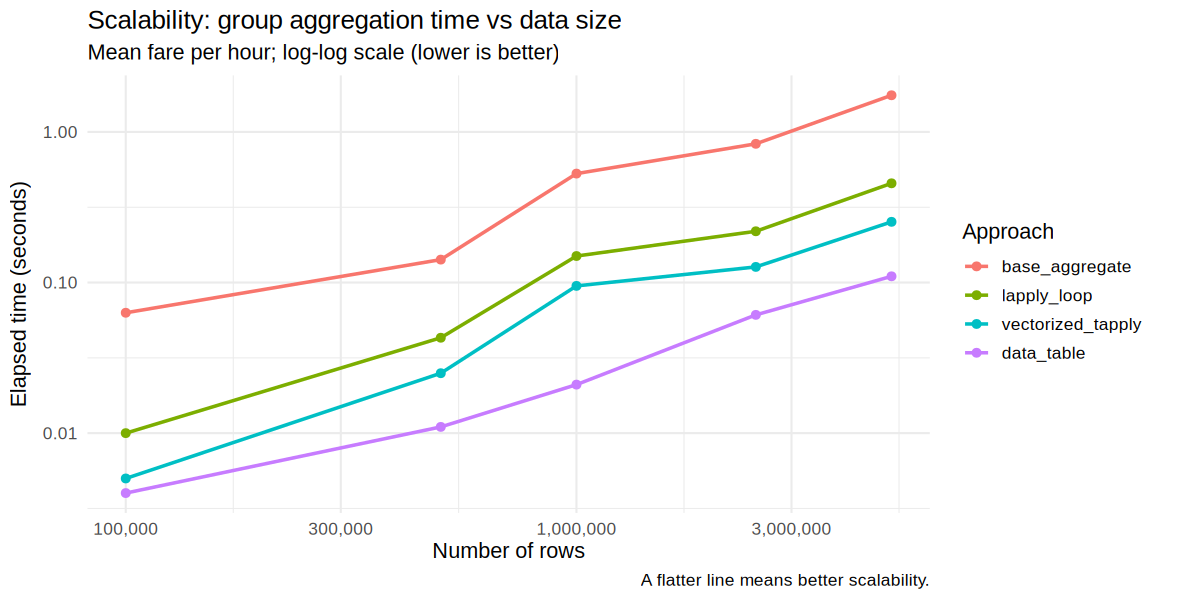

In [ ]:
scale_res <- rbindlist(lapply(SCALE_SIZES, function(n) {
  d  <- take(n)[, .(hour, fare_amount)]
  df <- as.data.frame(d)
  data.table(
    rows = n,
    base_aggregate    = system.time(aggregate(fare_amount ~ hour, data = df, FUN = mean))[["elapsed"]],
    lapply_loop       = system.time(lapply(hours, function(h) mean(df$fare_amount[df$hour == h])))[["elapsed"]],
    vectorized_tapply = system.time(tapply(df$fare_amount, df$hour, mean))[["elapsed"]],
    data_table        = system.time(d[, mean(fare_amount), by = hour])[["elapsed"]]
  )
}))
print(scale_res[, lapply(.SD, function(x) round(x, 4))])

scale_long <- melt(scale_res, id.vars = "rows", variable.name = "approach", value.name = "seconds")
ggplot(scale_long, aes(rows, seconds, colour = approach)) +
  geom_line(linewidth = 1) + geom_point(size = 2) +
  scale_x_log10(labels = comma) + scale_y_log10() +
  labs(title = "Scalability: group aggregation time vs data size",
       subtitle = "Mean fare per hour; log-log scale (lower is better)",
       x = "Number of rows", y = "Elapsed time (seconds)", colour = "Approach",
       caption = "A flatter line means better scalability.")

slopes <- scale_long[, .(slope = coef(lm(log10(seconds) ~ log10(rows)))[2]), by = approach]
cat("\nEmpirical scaling exponent (time ~ rows^slope; 1 = linear growth):\n")
print(slopes[, slope := round(slope, 2)])

### 5.5 Memory utilisation

In [ ]:
mem_res <- tryCatch({
  mm <- bench::mark(
    base_aggregate    = aggregate(fare_amount ~ hour, data = sdf, FUN = mean),
    lapply_loop       = lapply(hours, function(h) mean(sdf$fare_amount[sdf$hour == h])),
    purrr_map         = map_dbl(hours, ~ mean(sdf$fare_amount[sdf$hour == .x])),
    vectorized_rowsum = { rs <- rowsum(sdf$fare_amount, sdf$hour); rn <- rowsum(rep(1, nrow(sdf)), sdf$hour); as.numeric(rs[as.character(hours), 1] / rn[as.character(hours), 1]) },
    data_table        = sdt[, .(m = mean(fare_amount)), keyby = hour],
    iterations = 3, check = FALSE)
  data.table(approach = as.character(mm$expression),
             median_ms = round(as.numeric(mm$median) * 1000, 2),
             memory_allocated_MB = round(as.numeric(mm$mem_alloc) / 1024^2, 2))
}, error = function(e) { cat("bench::mark memory profiling unavailable:", conditionMessage(e), "\n"); NULL })
if (!is.null(mem_res)) print(mem_res)


cat(sprintf(
  "\nStorage footprint: cleaned table %.0f MB; raw table %.0f MB. Memory changed by %.1f%%.\n",
  mem_clean,
  mem_raw,
  100 * (mem_clean - mem_raw) / mem_raw
))

cat(sprintf("1M-row sample: data.frame %.0f MB vs data.table %.0f MB\n",
            as.numeric(object.size(sdf)) / 1024^2, as.numeric(object.size(sdt)) / 1024^2))

            approach median_ms memory_allocated_MB
              <char>     <num>               <num>
1:    base_aggregate    460.07              189.15
2:       lapply_loop     86.56              194.57
3:         purrr_map     87.04              194.55
4: vectorized_rowsum     40.63               38.89
5:        data_table     20.26               28.11

Storage footprint: cleaned table 1456 MB; raw table 1413 MB. Memory changed by 3.1%.
1M-row sample: data.frame 38 MB vs data.table 38 MB


### 5.6 Why do the implementations differ in speed? (discussion)

- **`apply()` / `lapply()` over rows:** the R interpreter calls an R-level function once per row (100,000 calls), allocating a small vector each time. `apply()` additionally converts the data to a matrix first. Function-call overhead and memory allocation dominate the cost.
- **`purrr::map*`:** same one-call-per-element structure plus formula-lambda overhead; it is more *readable* than a loop but not faster than `lapply()`. It shines for lists, nested data and pipelines, not for numeric columns.
- **Group-wise `lapply()` / `map_dbl()` loops over 24 hours:** each iteration re-scans the whole column (`sdf$hour == h`), so the work is 24 full passes over the data. Only 24 R-level calls are made, so overhead is small, but the repeated scans cost time.
- **Vectorized operations** (`fare / distance`, `rowsum()`, `match()`): one call to compiled C code loops over contiguous memory with no per-element interpreter overhead.
- **`data.table`:** grouping uses a radix-based algorithm in C, `mean`/`sum` with `by` are replaced by optimised internal "GForce" versions, work is multi-threaded, and `:=` / update-joins modify columns **by reference** instead of copying the table. This gives the best time *and* the lowest memory allocation, and the gap widens as the data grows (see the scalability plot).
- **`merge()` vs `data.table` join:** `merge()` sorts and copies both tables; data.table joins on a keyed/indexed table without copying the large side. A plain `match()` lookup is also fast but only works for a single lookup column.

The exact numbers above come from your run; the *ranking* (loops over rows slowest, vectorized and data.table fastest) is expected to be stable.

## 6. Task 4: Parallel Computing (foreach + doParallel)

**Partitioning:** the cleaned data is split month-wise into logical partitions (one `data.table` per month).

**Computationally intensive operation (per month):**
1. route-level statistics: median and 90th-percentile fare for every pickup-drop-off route (tens of thousands of groups, `quantile()` is relatively expensive);
2. a **bootstrap** (resampling with replacement) of the mean fare-per-mile with a 95% confidence interval.

The same function is run **sequentially** (`lapply`) and **in parallel** (`foreach` + `%dopar%`). `data.table` is itself multi-threaded, so its threads are set to **1** for these experiments, otherwise the "sequential" run would already be using several cores and the comparison would be unfair. The seed is fixed per month so both versions must give identical results.

In [ ]:


# --- Partition data by pickup month ---
parts <- split(
  dt[, .(
    pickup_month,
    PULocationID,
    DOLocationID,
    trip_distance,
    fare_amount,
    total_amount
  )],
  by = "pickup_month"
)

cat(
  "Partitions:", length(parts),
  "| rows per month:",
  paste(comma(sapply(parts, nrow)), collapse = ", "),
  "\n"
)

# --- Heavy analysis function ---
heavy_analysis <- function(d, B = BOOT_B, n_boot = N_BOOT) {
  set.seed(1000L + as.integer(d$pickup_month[1]))

  # 1. Route-level distribution statistics
  rs <- d[, .(
    trips = .N,
    med_fare = median(fare_amount, na.rm = TRUE),
    p90_fare = if (all(is.na(fare_amount))) NA_real_ else
      quantile(fare_amount, 0.9, na.rm = TRUE, names = FALSE)
  ), by = .(PULocationID, DOLocationID)]

  # 2. Bootstrap confidence interval for mean fare per mile
  x <- d$fare_amount / d$trip_distance
  x <- x[is.finite(x) & !is.na(x)]

  if (length(x) == 0L) {
    return(data.table(
      month = d$pickup_month[1],
      trips = nrow(d),
      routes = nrow(rs),
      boot_mean_fare_per_mile = NA_real_,
      ci_low = NA_real_,
      ci_high = NA_real_
    ))
  }

  x <- x[sample.int(length(x), min(n_boot, length(x)))]

  boot <- replicate(
    B,
    mean(sample(x, length(x), replace = TRUE))
  )

  data.table(
    month = d$pickup_month[1],
    trips = nrow(d),
    routes = nrow(rs),
    boot_mean_fare_per_mile = mean(boot),
    ci_low = unname(quantile(boot, 0.025)),
    ci_high = unname(quantile(boot, 0.975))
  )
}

# --- Configure parallel workers ---
orig_threads <- data.table::getDTthreads()

visible_cores <- parallel::detectCores(logical = TRUE)

if (is.na(visible_cores)) {
  visible_cores <- 2L
}


# Use two workers for the parallel analysis
n_cores <- min(2L, length(parts))

cat("Cores used for the parallel run:", n_cores, "\n")




Partitions: 6 | rows per month: 2,872,795, 2,721,801, 3,177,322, 3,064,614, 3,268,154, 3,072,524 
Cores used for the parallel run: 2 


### 6.1 Sequential vs parallel execution and speedup

In [ ]:
setDTthreads(1)

# A. Sequential
t_seq <- system.time(res_seq <- rbindlist(lapply(parts, heavy_analysis)))[["elapsed"]]

# B. Parallel with foreach + doParallel
registerDoParallel(cores = n_cores)
t_par <- system.time(
  res_par <- foreach(d = parts, .combine = rbind, .packages = "data.table", .export = "heavy_analysis") %dopar% {
    setDTthreads(1)
    heavy_analysis(d)
  }
)[["elapsed"]]

speedup    <- t_seq / t_par
efficiency <- speedup / n_cores
cat(sprintf("Sequential (lapply)     : %6.2f s\n", t_seq))
cat(sprintf("Parallel (%d cores)      : %6.2f s\n", n_cores, t_par))
cat(sprintf("\nSpeedup    = %.2f / %.2f = %.2fx\n", t_seq, t_par, speedup))
cat(sprintf("Efficiency = speedup / cores = %.0f%%\n", 100 * efficiency))
cat("Parallel results identical to sequential:", isTRUE(all.equal(res_seq[order(month)], res_par[order(month)])), "\n\n")
print(res_par[order(month)][, lapply(.SD, function(x) if (is.numeric(x)) round(x, 3) else x)])

Sequential (lapply)     :  29.27 s
Parallel (2 cores)      :  27.50 s

Speedup    = 29.27 / 27.50 = 1.06x
Efficiency = speedup / cores = 53%
Parallel results identical to sequential: TRUE 

   month   trips routes boot_mean_fare_per_mile ci_low ci_high
   <num>   <num>  <num>                   <num>  <num>   <num>
1:     1 2872795  20668                   7.628  7.514   7.790
2:     2 2721801  20392                   7.655  7.583   7.737
3:     3 3177322  21793                   7.940  7.798   8.088
4:     4 3064614  21752                   7.934  7.775   8.142
5:     5 3268154  22240                   8.209  8.083   8.334
6:     6 3072524  21739                   8.106  7.983   8.237


### 6.2 Effect of the number of cores, and a lightweight task (when parallelism does NOT help)

   cores seconds speedup efficiency_pct
   <int>   <num>   <num>          <num>
1:     1   30.51    0.96             96
2:     2   27.50    1.06             53
        expr       min    median      mean       max
1 sequential  25.56007  50.67476  48.70917  81.97315
2   parallel 105.34613 115.63578 124.22990 147.48672

Lightweight task: sequential 50.7 ms vs parallel 115.6 ms -> parallel is 2.3x SLOWER


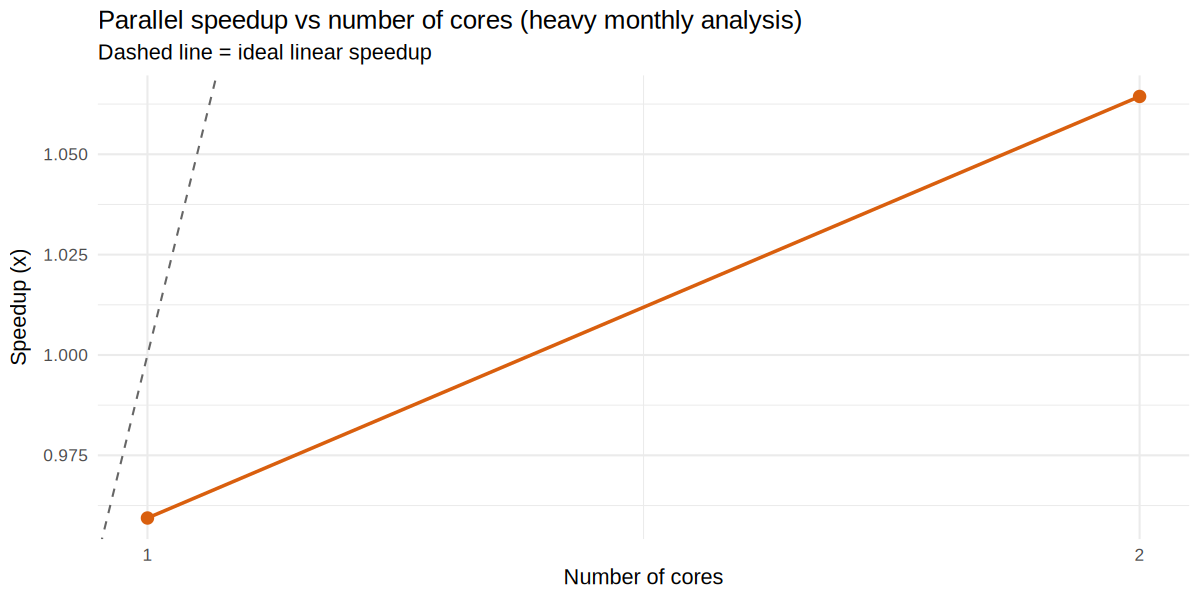

In [ ]:
# Scaling with number of workers (the run with n_cores workers was already timed above)
core_grid <- sort(unique(c(1L, 2L, min(4L, max(detectCores(), 2L)))))
core_grid <- setdiff(core_grid[core_grid <= length(parts)], n_cores)
core_res <- rbindlist(c(
  lapply(core_grid, function(k) {
    registerDoParallel(cores = k)
    tm <- system.time(
      foreach(d = parts, .combine = rbind, .packages = "data.table", .export = "heavy_analysis") %dopar% {
        setDTthreads(1); heavy_analysis(d) })[["elapsed"]]
    data.table(cores = k, seconds = tm)
  }),
  list(data.table(cores = n_cores, seconds = t_par))
))
setorder(core_res, cores)
core_res[, `:=`(speedup = t_seq / seconds, efficiency_pct = round(100 * (t_seq / seconds) / cores))]
print(core_res[, .(cores, seconds = round(seconds, 2), speedup = round(speedup, 2), efficiency_pct)])

# A cheap task: the work per partition is tiny, so overhead dominates
light_fn <- function(d) d[, .(trips = .N, revenue = sum(total_amount))]
registerDoParallel(cores = n_cores)
mb_light <- microbenchmark(
  sequential = rbindlist(lapply(parts, light_fn)),
  parallel   = foreach(d = parts, .combine = rbind, .packages = "data.table", .export = "light_fn") %dopar% light_fn(d),
  times = 10
)
print(summary(mb_light, unit = "ms")[, c("expr", "min", "median", "mean", "max")])
light_seq_ms <- median(mb_light$time[mb_light$expr == "sequential"]) / 1e6
light_par_ms <- median(mb_light$time[mb_light$expr == "parallel"]) / 1e6
cat(sprintf("\nLightweight task: sequential %.1f ms vs parallel %.1f ms -> parallel is %.1fx %s\n",
            light_seq_ms, light_par_ms, ifelse(light_par_ms > light_seq_ms, light_par_ms / light_seq_ms, light_seq_ms / light_par_ms),
            ifelse(light_par_ms > light_seq_ms, "SLOWER", "faster")))

registerDoSEQ(); setDTthreads(orig_threads)

ggplot(core_res, aes(cores, speedup)) +
  geom_line(colour = "#d95f0e", linewidth = 1) + geom_point(size = 3, colour = "#d95f0e") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey40") +
  scale_x_continuous(breaks = core_res$cores) +
  labs(title = "Parallel speedup vs number of cores (heavy monthly analysis)",
       subtitle = "Dashed line = ideal linear speedup", x = "Number of cores", y = "Speedup (x)")

### 6.3 Discussion of the parallel results

- For the **heavy** task (thousands of `quantile()` calls plus hundreds of bootstrap resamples per month) each partition takes several seconds, so the one-off cost of forking workers and collecting results is small relative to the work, and parallelism is expected to pay off when more than one core is available (compare with your measured speedup above). The speedup is below the ideal value because of Amdahl's law (sequential parts such as splitting data and combining results), fork/scheduling overhead, and **load imbalance** (months have different sizes and six jobs do not divide evenly over every core count).
- Colab provides only **2 vCPUs**, so a speedup close to 2x is the theoretical maximum here; on an 8-core machine more would be possible.
- For the **lightweight** task, each partition aggregates in a few milliseconds, which is less than the cost of dispatching work to workers, so parallel execution is **slower** (or no faster). Parallelism is therefore **not always beneficial**: it only helps when computation per task clearly exceeds the communication/startup overhead.
- On Linux `doParallel` with `cores =` uses forking, so workers share memory with the parent (copy-on-write). A PSOCK cluster (the only option on Windows) would have to copy the data to every worker, which adds even more overhead and memory use.

## 7. Task 5: Performance Benchmarking and Optimization

In [ ]:
paradigm <- c(base_aggregate = "Base R", base_tapply = "Vectorized", lapply_loop = "Functional", purrr_map = "Functional",
              vectorized_rowsum = "Vectorized", data_table = "data.table",
              apply_rows = "Functional", lapply_rows = "Functional", purrr_map2 = "Functional",
              vectorized = "Vectorized", data_table_set = "data.table",
              base_merge = "Base R", base_match = "Vectorized",
              sequential = "Sequential", parallel = "Parallel",
              `Sequential (lapply)` = "Sequential", `Parallel (foreach + doParallel)` = "Parallel")

mb_to_dt <- function(mb, comparison) {
  s <- as.data.table(summary(mb, unit = "ms"))
  data.table(Comparison = comparison, Approach = as.character(s$expr),
             Median_ms = pmax(round(s$median, 3), 0.001), Mean_ms = pmax(round(s$mean, 3), 0.001))
}

bench_table <- rbindlist(list(
  mb_to_dt(mb_group, "A. Group aggregation (mean fare/hour)"),
  mb_to_dt(mb_row,   "B. Row-wise calculation (fare/mile)"),
  mb_to_dt(mb_join,  "C. Join with zone table"),
  data.table(Comparison = "D. Heavy monthly analysis (6 partitions)",
             Approach = c("Sequential (lapply)", "Parallel (foreach + doParallel)"),
             Median_ms = round(c(t_seq, t_par) * 1000, 1), Mean_ms = round(c(t_seq, t_par) * 1000, 1)),
  mb_to_dt(mb_light, "E. Lightweight monthly aggregation (6 partitions)")
))
bench_table[, Paradigm := ifelse(is.na(paradigm[Approach]), "Other", paradigm[Approach])]
bench_table[, Relative_to_fastest := round(Median_ms / min(Median_ms), 1), by = Comparison]
bench_table[, Approach := ifelse(Approach == "Sequential (lapply)", "sequential", ifelse(Approach == "Parallel (foreach + doParallel)", "parallel", Approach))]

cat("EXECUTION-TIME COMPARISON TABLE (median ms; lower is better)\n\n")
print(bench_table[, .(Comparison, Approach, Paradigm, Median_ms, Mean_ms, Relative_to_fastest)], row.names = FALSE)

EXECUTION-TIME COMPARISON TABLE (median ms; lower is better)

                                        Comparison          Approach   Paradigm
                                            <char>            <char>     <char>
             A. Group aggregation (mean fare/hour)    base_aggregate     Base R
             A. Group aggregation (mean fare/hour)       base_tapply Vectorized
             A. Group aggregation (mean fare/hour)       lapply_loop Functional
             A. Group aggregation (mean fare/hour)         purrr_map Functional
             A. Group aggregation (mean fare/hour) vectorized_rowsum Vectorized
             A. Group aggregation (mean fare/hour)        data_table data.table
               B. Row-wise calculation (fare/mile)        apply_rows Functional
               B. Row-wise calculation (fare/mile)       lapply_rows Functional
               B. Row-wise calculation (fare/mile)        purrr_map2 Functional
               B. Row-wise calculation (fare/mile)        

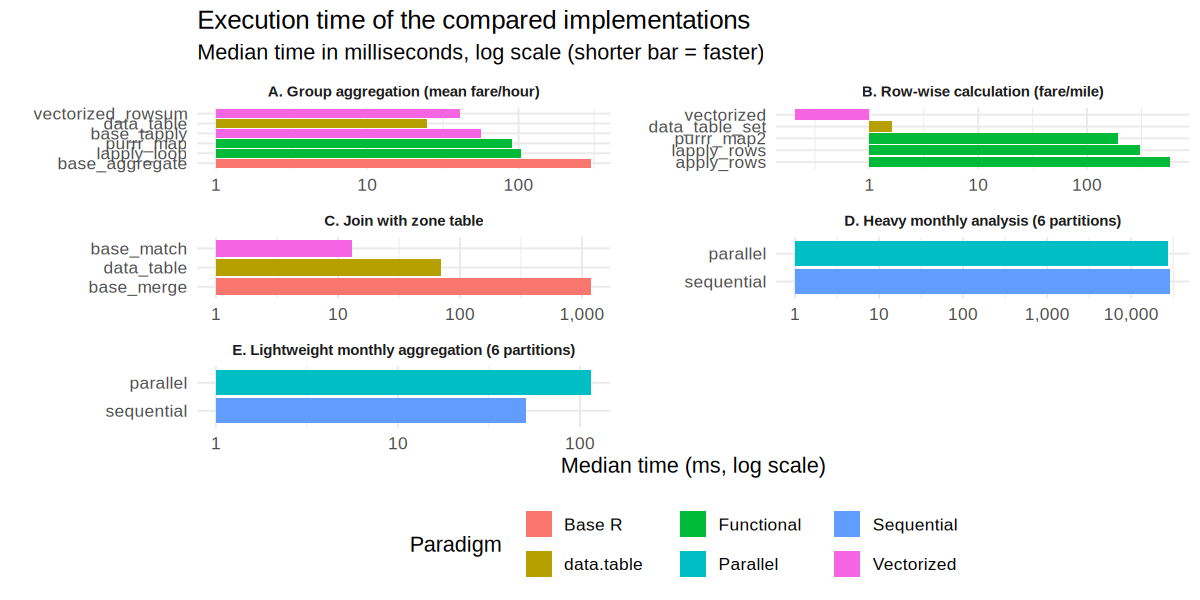

In [ ]:
ggplot(bench_table, aes(reorder(Approach, -Median_ms), Median_ms, fill = Paradigm)) +
  geom_col() + coord_flip() + facet_wrap(~ Comparison, scales = "free", ncol = 2) +
  scale_y_log10(labels = comma) +
  labs(title = "Execution time of the compared implementations",
       subtitle = "Median time in milliseconds, log scale (shorter bar = faster)",
       x = NULL, y = "Median time (ms, log scale)", fill = "Paradigm") +
  theme(legend.position = "bottom", strip.text = element_text(face = "bold", size = 9))

### 7.1 Qualitative comparison of the approaches

| Criterion | Base R (`aggregate`, `merge`) | Functional (`apply`, `lapply`, `purrr`) | Vectorized | data.table | Parallel (`foreach`) |
|---|---|---|---|---|---|
| **Execution time** | moderate to slow | slowest for per-row work | very fast | fastest for grouping/joins | faster only for heavy tasks |
| **Memory** | copies data frequently | many small temporary objects | one result vector | lowest (in-place `:=`, joins by reference) | higher: one copy of data/results per worker |
| **Scalability** | degrades with size | poor for row-wise use | good | best (multi-threaded, ~linear) | limited by cores and overhead |
| **Code complexity** | low | low to medium | low | low once syntax is known | highest (setup, exports, seeds) |
| **Readability** | high | high (`purrr` very readable) | high | compact but needs `DT[i, j, by]` knowledge | lower |

**Why data.table and vectorization win on big data:** both push the loop from interpreted R into compiled C/C++, work on contiguous column vectors, avoid copies, and (data.table) use optimised grouping algorithms and multiple threads. Functional tools are convenient but still make one R-level function call per element.

## 8. Task 6: Data Visualization (ggplot2)

Each figure has a title, axis labels with units, a legend where a colour is used, and a short interpretation.

Interpretation: demand is lowest at 04:00 and peaks at 18:00; the busiest time period is 'Midday (10-15)' with 33.1% of all trips.


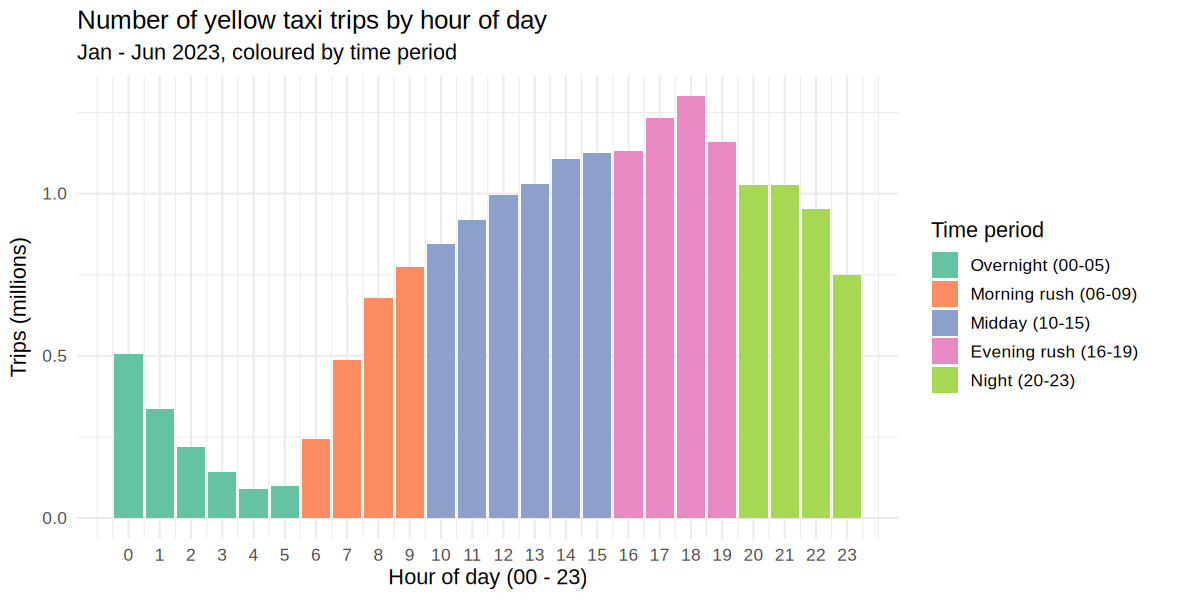

In [ ]:
ggplot(hourly, aes(hour, trips / 1e6, fill = period)) +
  geom_col() +
  scale_x_continuous(breaks = 0:23) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Number of yellow taxi trips by hour of day",
       subtitle = "Jan - Jun 2023, coloured by time period",
       x = "Hour of day (00 - 23)", y = "Trips (millions)", fill = "Time period")
cat(sprintf("Interpretation: demand is lowest at %02d:00 and peaks at %02d:00; the busiest time period is '%s' with %.1f%% of all trips.\n",
            hourly[which.min(trips), hour], hourly[which.max(trips), hour],
            hourly[, .(t = sum(trips)), by = period][which.max(t), period],
            100 * hourly[, .(t = sum(trips)), by = period][, max(t) / sum(t)]))

Interpretation: Thu is the busiest day and Mon the quietest; average weekday volume is 2,660,430 trips per day-of-week vs 2,437,529 at weekends.


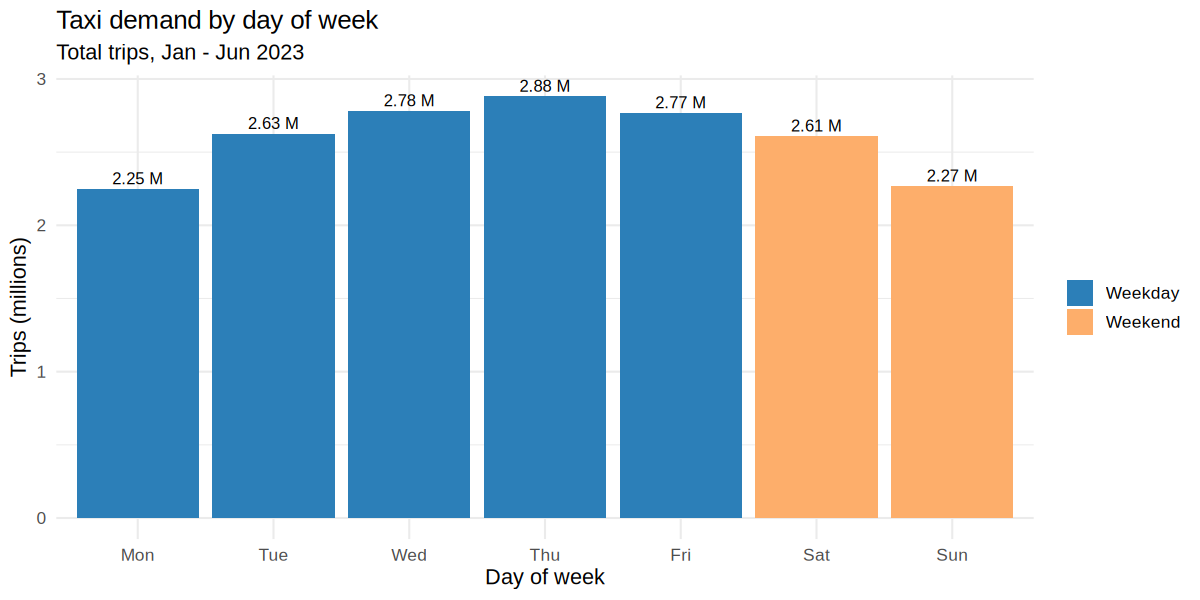

In [ ]:
dow_tbl[, day_type := ifelse(day_name %in% c("Sat", "Sun"), "Weekend", "Weekday")]
ggplot(dow_tbl, aes(day_name, trips / 1e6, fill = day_type)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.2f M", trips / 1e6)), vjust = -0.4, size = 3.5) +
  scale_fill_manual(values = c(Weekday = "#2c7fb8", Weekend = "#fdae6b")) +
  labs(title = "Taxi demand by day of week", subtitle = "Total trips, Jan - Jun 2023",
       x = "Day of week", y = "Trips (millions)", fill = NULL)
cat(sprintf("Interpretation: %s is the busiest day and %s the quietest; average weekday volume is %s trips per day-of-week vs %s at weekends.\n",
            dow_tbl[which.max(trips), day_name], dow_tbl[which.min(trips), day_name],
            comma(round(dow_tbl[day_type == "Weekday", mean(trips)])), comma(round(dow_tbl[day_type == "Weekend", mean(trips)]))))

Interpretation: May has the most trips and May the highest revenue; the correlation between monthly trips and revenue is 0.98, and average fares vary only between $18.41 and $20.05.


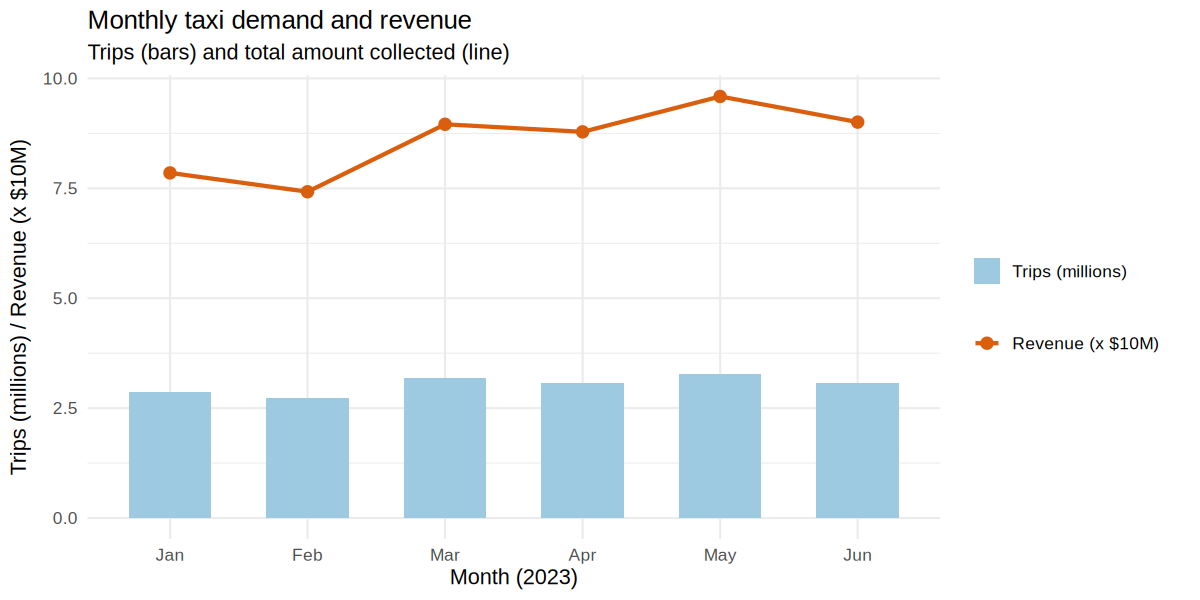

In [ ]:
ggplot(monthly, aes(month_name, trips / 1e6, group = 1)) +
  geom_col(aes(fill = "Trips (millions)"), width = 0.6) +
  geom_line(aes(y = revenue / 1e7, colour = "Revenue (x $10M)"), linewidth = 1.2) +
  geom_point(aes(y = revenue / 1e7, colour = "Revenue (x $10M)"), size = 3) +
  scale_fill_manual(values = c("Trips (millions)" = "#9ecae1")) +
  scale_colour_manual(values = c("Revenue (x $10M)" = "#d95f0e")) +
  labs(title = "Monthly taxi demand and revenue", subtitle = "Trips (bars) and total amount collected (line)",
       x = "Month (2023)", y = "Trips (millions) / Revenue (x $10M)", fill = NULL, colour = NULL)
cat(sprintf("Interpretation: %s has the most trips and %s the highest revenue; the correlation between monthly trips and revenue is %.2f, and average fares vary only between $%.2f and $%.2f.\n",
            monthly[which.max(trips), month_name], monthly[which.max(revenue), month_name],
            ifelse(nrow(monthly) > 2, cor(monthly$trips, monthly$revenue), NA), min(monthly$avg_fare), max(monthly$avg_fare)))

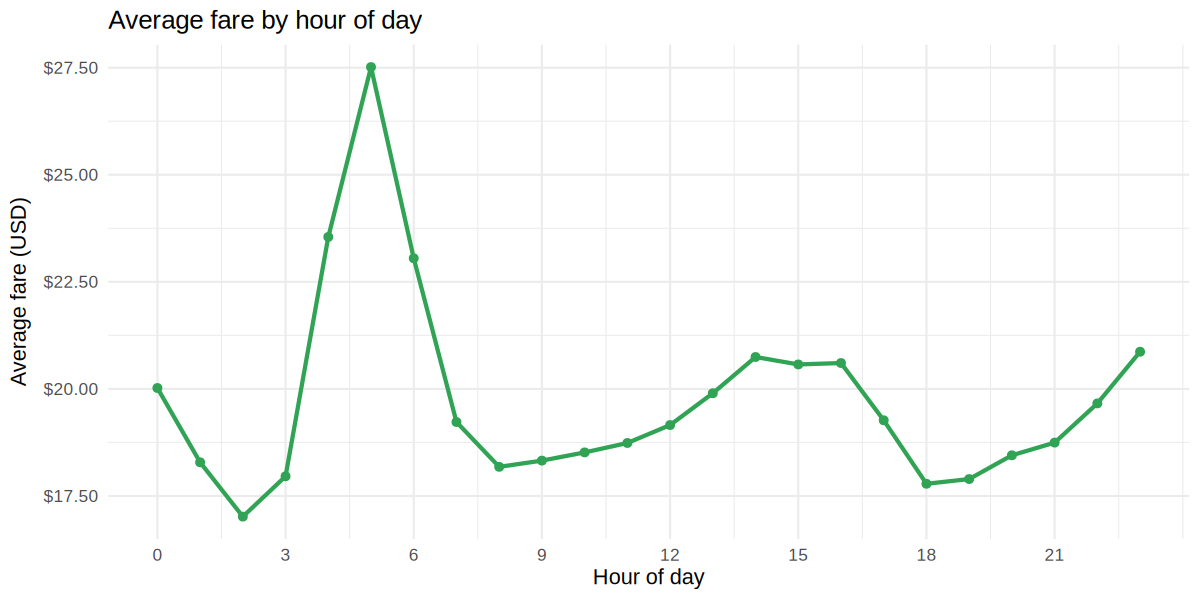

Interpretation: the average fare peaks at 05:00 ($27.51), (trip length and time of day both influence the fare); month-to-month fares are stable (range $18.41 to $20.05).


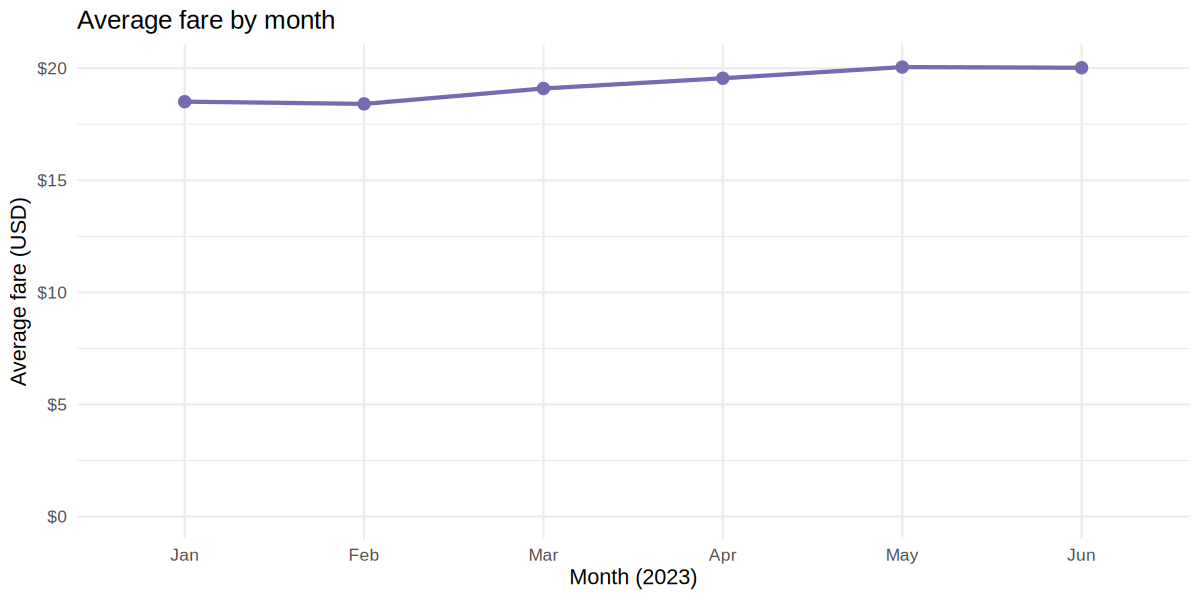

In [ ]:
p1 <- ggplot(hourly, aes(hour, avg_fare)) +
  geom_line(colour = "#31a354", linewidth = 1.2) + geom_point(colour = "#31a354", size = 2) +
  scale_x_continuous(breaks = seq(0, 23, 3)) + scale_y_continuous(labels = dollar) +
  labs(title = "Average fare by hour of day", x = "Hour of day", y = "Average fare (USD)")
p2 <- ggplot(monthly, aes(month_name, avg_fare, group = 1)) +
  geom_line(colour = "#756bb1", linewidth = 1.2) + geom_point(colour = "#756bb1", size = 3) +
  scale_y_continuous(labels = dollar, limits = c(0, NA)) +
  labs(title = "Average fare by month", x = "Month (2023)", y = "Average fare (USD)")
if (requireNamespace("gridExtra", quietly = TRUE)) gridExtra::grid.arrange(p1, p2, ncol = 2) else { print(p1); print(p2) }
cat(sprintf("Interpretation: the average fare peaks at %02d:00 ($%.2f), (trip length and time of day both influence the fare); month-to-month fares are stable (range $%.2f to $%.2f).\n",
            hourly[which.max(avg_fare), hour], max(hourly$avg_fare), min(monthly$avg_fare), max(monthly$avg_fare)))

Interpretation: revenue fluctuates with a weekly cycle (the 7-day average smooths it); the best day collected $3.83 M (2023-05-18) and the weakest $1.93 M (2023-01-02).


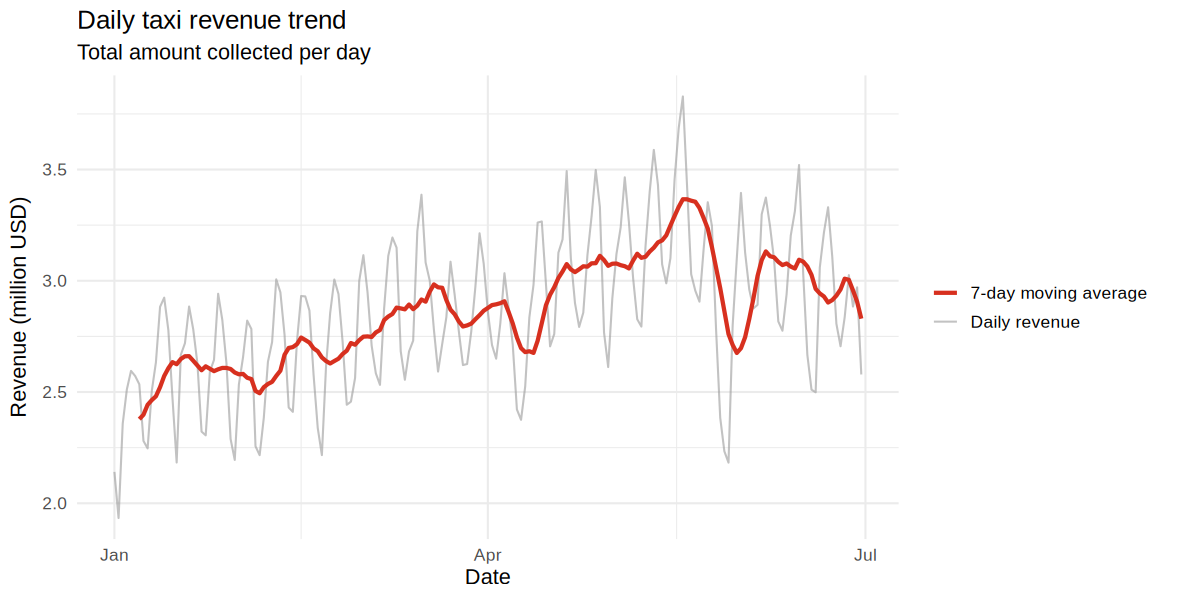

In [ ]:
daily <- dt[, .(revenue = sum(total_amount), trips = .N), keyby = pickup_date]
daily[, ma7 := frollmean(revenue, 7)]
ggplot(daily, aes(pickup_date)) +
  geom_line(aes(y = revenue / 1e6, colour = "Daily revenue"), alpha = 0.6) +
  geom_line(aes(y = ma7 / 1e6, colour = "7-day moving average"), linewidth = 1.2, na.rm = TRUE) +
  scale_colour_manual(values = c("Daily revenue" = "grey60", "7-day moving average" = "#d7301f")) +
  labs(title = "Daily taxi revenue trend", subtitle = "Total amount collected per day",
       x = "Date", y = "Revenue (million USD)", colour = NULL)
cat(sprintf("Interpretation: revenue fluctuates with a weekly cycle (the 7-day average smooths it); the best day collected $%.2f M (%s) and the weakest $%.2f M (%s).\n",
            max(daily$revenue) / 1e6, format(daily[which.max(revenue), pickup_date]),
            min(daily$revenue) / 1e6, format(daily[which.min(revenue), pickup_date])))

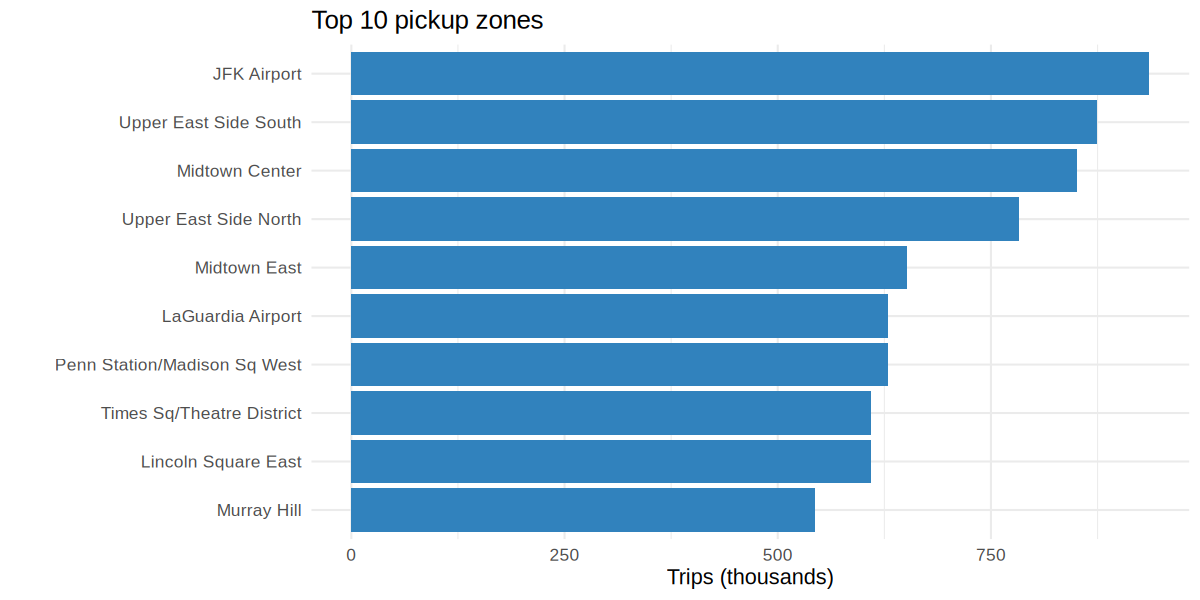

Interpretation: 'JFK Airport' (Queens) is the most popular pickup zone and 'Upper East Side North' the most popular drop-off zone; 18 of these 20 zone entries are in Manhattan, showing how strongly demand concentrates in a few central and transport-hub zones.


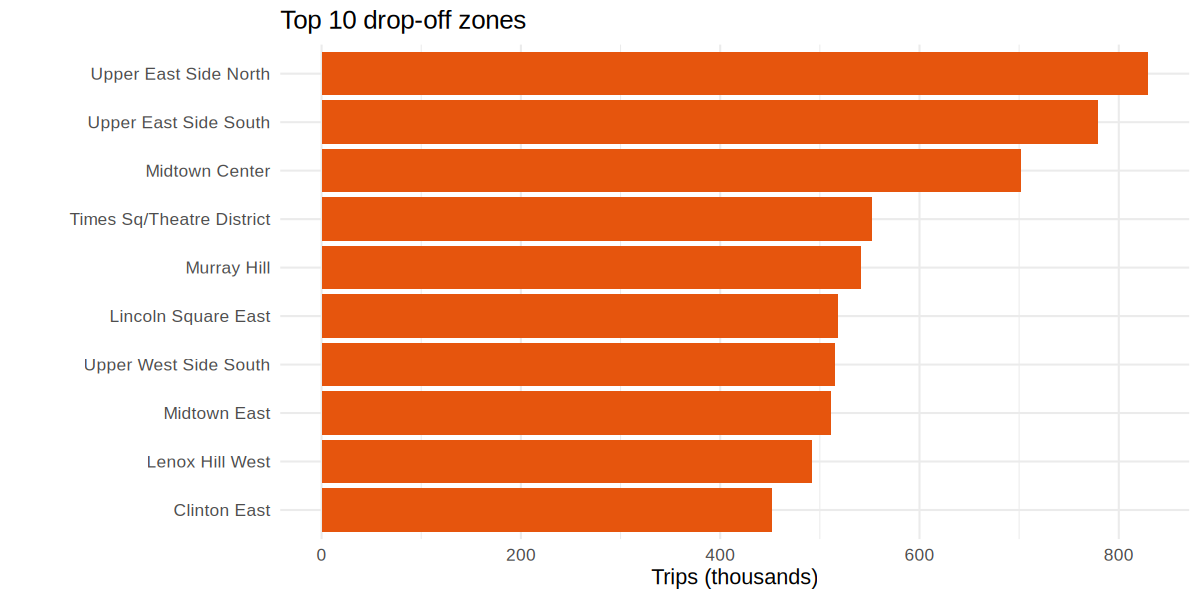

In [ ]:
p_pu <- ggplot(top_pu, aes(reorder(PU_Zone, trips), trips / 1e3)) +
  geom_col(fill = "#3182bd") + coord_flip() +
  labs(title = "Top 10 pickup zones", x = NULL, y = "Trips (thousands)")
p_do <- ggplot(top_do, aes(reorder(DO_Zone, trips), trips / 1e3)) +
  geom_col(fill = "#e6550d") + coord_flip() +
  labs(title = "Top 10 drop-off zones", x = NULL, y = "Trips (thousands)")
if (requireNamespace("gridExtra", quietly = TRUE)) gridExtra::grid.arrange(p_pu, p_do, ncol = 2) else { print(p_pu); print(p_do) }
top_pu_b <- zones[Zone == top_pu$PU_Zone[1], Borough][1]
n_manh   <- sum(zones[match(c(top_pu$PU_Zone, top_do$DO_Zone), zones$Zone), Borough] == "Manhattan", na.rm = TRUE)
cat(sprintf("Interpretation: '%s' (%s) is the most popular pickup zone and '%s' the most popular drop-off zone; %d of these 20 zone entries are in Manhattan, showing how strongly demand concentrates in a few central and transport-hub zones.\n",
            top_pu$PU_Zone[1], top_pu_b, top_do$DO_Zone[1], n_manh))

Interpretation: the 15 most frequent routes average 2.4 miles and $14.18 per trip versus 3.5 miles overall; frequency is driven by routes where the same short trip is repeated very often (3 of the 15 start and end in the same zone).


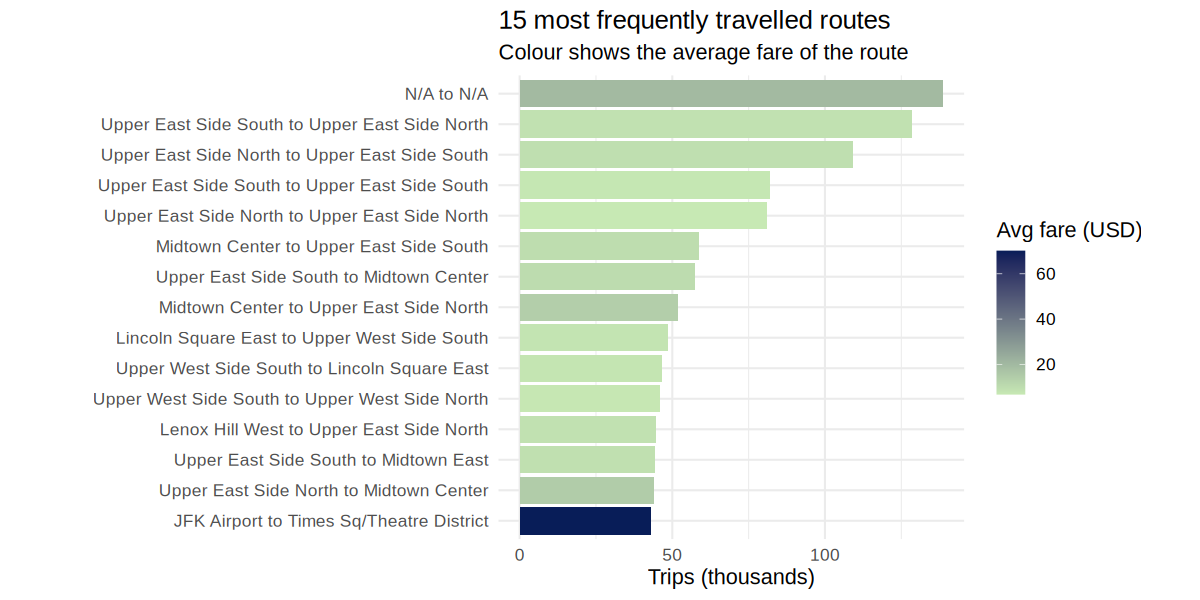

In [ ]:
ggplot(top_routes_freq, aes(reorder(route, trips), trips / 1e3, fill = avg_fare)) +
  geom_col() + coord_flip() +
  scale_fill_gradient(low = "#c7e9b4", high = "#081d58") +
  labs(title = "15 most frequently travelled routes", subtitle = "Colour shows the average fare of the route",
       x = NULL, y = "Trips (thousands)", fill = "Avg fare (USD)")
overall_avg_dist <- dt[, mean(trip_distance)]
cat(sprintf("Interpretation: the 15 most frequent routes average %.1f miles and $%.2f per trip versus %.1f miles overall; frequency is driven by routes where the same short trip is repeated very often (%d of the 15 start and end in the same zone).\n",
            mean(top_routes_freq$avg_distance), mean(top_routes_freq$avg_fare), overall_avg_dist,
            sum(top_routes_freq$PULocationID == top_routes_freq$DOLocationID)))

Interpretation: the 15 highest-revenue routes average 13.5 miles (vs 2.4 for the 15 most frequent routes) and $56.69 per trip (vs $14.18); 4 routes appear in both lists. Revenue is the product of frequency and fare, so long, expensive routes can rank high despite fewer trips.


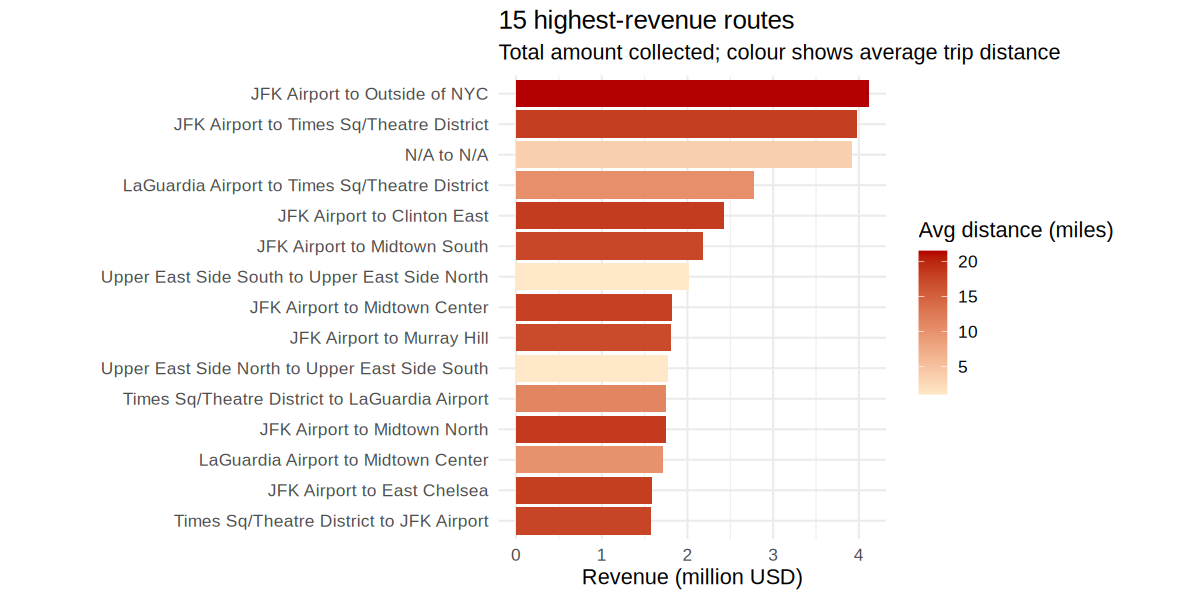

In [ ]:
ggplot(top_routes_rev, aes(reorder(route, revenue), revenue / 1e6, fill = avg_distance)) +
  geom_col() + coord_flip() +
  scale_fill_gradient(low = "#fee8c8", high = "#b30000") +
  labs(title = "15 highest-revenue routes", subtitle = "Total amount collected; colour shows average trip distance",
       x = NULL, y = "Revenue (million USD)", fill = "Avg distance (miles)")
cat(sprintf("Interpretation: the 15 highest-revenue routes average %.1f miles (vs %.1f for the 15 most frequent routes) and $%.2f per trip (vs $%.2f); %d routes appear in both lists. Revenue is the product of frequency and fare, so long, expensive routes can rank high despite fewer trips.\n",
            mean(top_routes_rev$avg_distance), mean(top_routes_freq$avg_distance),
            mean(top_routes_rev$avg_fare), mean(top_routes_freq$avg_fare),
            length(intersect(top_routes_freq$route, top_routes_rev$route))))

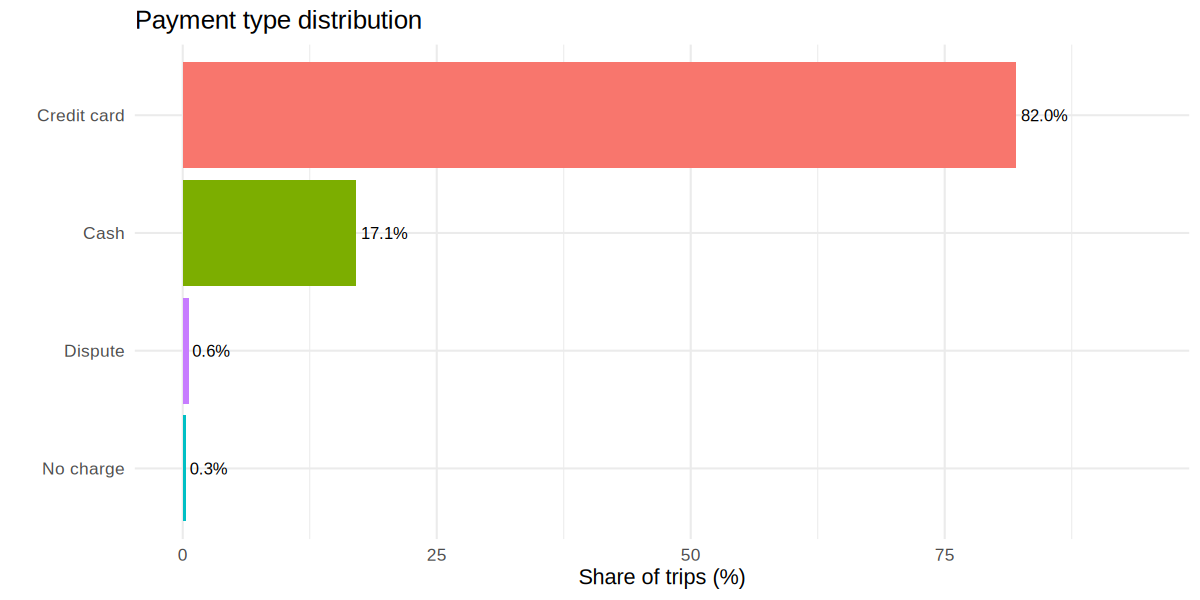

Interpretation: Credit card is the most common payment type overall (82.0% of trips) and the top method in 7 of 7 pickup boroughs; cash accounts for 17.1% of trips.


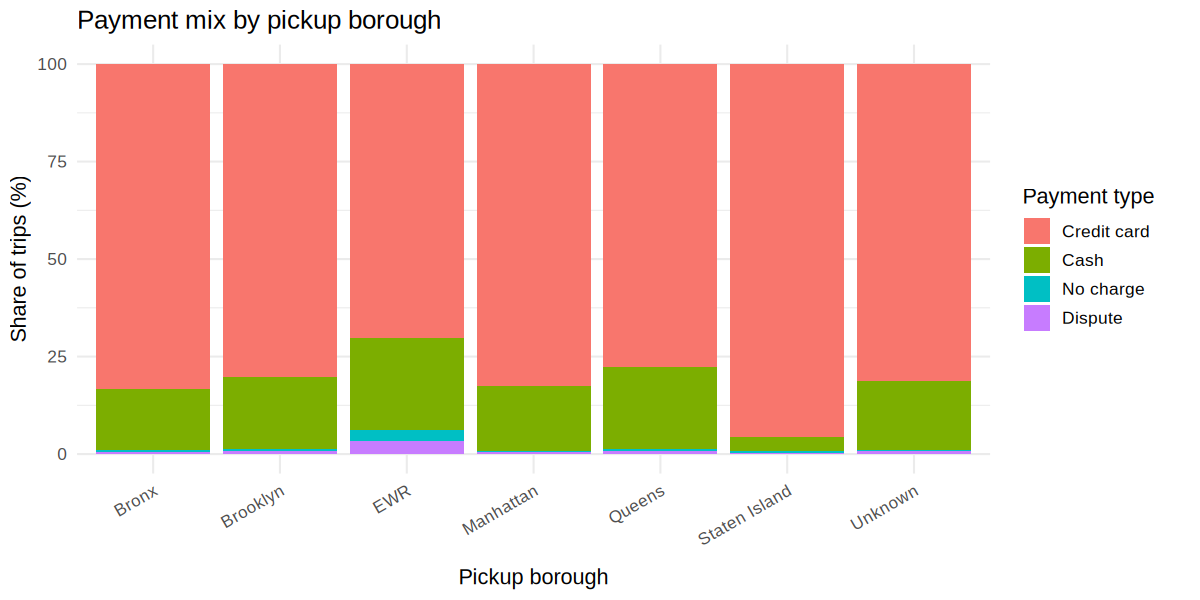

In [ ]:
p_pay <- ggplot(pay_overall, aes(reorder(payment_type, share), share, fill = payment_type)) +
  geom_col(show.legend = FALSE) + coord_flip() +
  geom_text(aes(label = sprintf("%.1f%%", share)), hjust = -0.1, size = 3.5) +
  scale_y_continuous(limits = c(0, max(pay_overall$share) * 1.15)) +
  labs(title = "Payment type distribution", x = NULL, y = "Share of trips (%)")
p_bor <- ggplot(pay_borough, aes(PU_Borough, share, fill = payment_type)) +
  geom_col(position = "stack") +
  labs(title = "Payment mix by pickup borough", x = "Pickup borough", y = "Share of trips (%)", fill = "Payment type") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))
if (requireNamespace("gridExtra", quietly = TRUE)) gridExtra::grid.arrange(p_pay, p_bor, ncol = 2, widths = c(1, 1.3)) else { print(p_pay); print(p_bor) }
top_by_b <- pay_borough[, .SD[which.max(share)], by = PU_Borough]
cash_share <- pay_overall[payment_type == "Cash", share]
cat(sprintf("Interpretation: %s is the most common payment type overall (%.1f%% of trips) and the top method in %d of %d pickup boroughs; cash accounts for %.1f%% of trips.\n",
            pay_overall$payment_type[1], pay_overall$share[1], sum(top_by_b$payment_type == pay_overall$payment_type[1]), nrow(top_by_b),
            ifelse(length(cash_share) == 0, 0, cash_share)))

Interpretation: fare rises almost linearly with distance (about $3.72 per mile plus $6.29 base, r = 0.96). Points that sit far from the line (for example a horizontal band of equal fares at different distances) correspond to flat-rate or time-based fares such as airport trips.


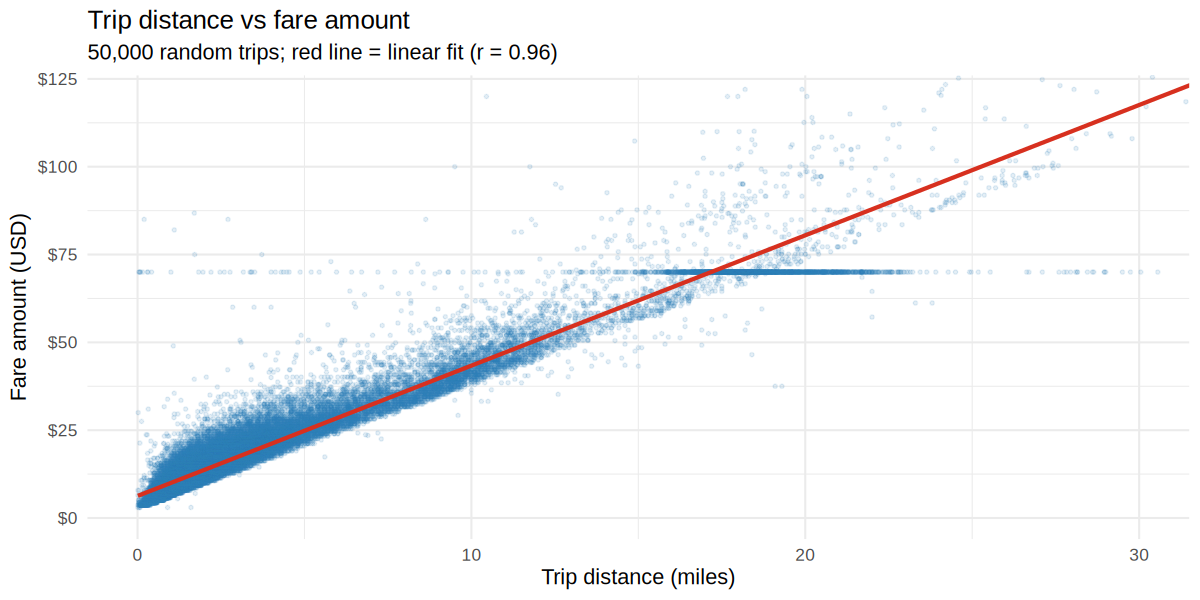

In [ ]:
set.seed(2)
vs <- dt[sample.int(.N, 50000), .(trip_distance, fare_amount)]
ggplot(vs, aes(trip_distance, fare_amount)) +
  geom_point(alpha = 0.12, size = 0.8, colour = "#2c7fb8") +
  geom_smooth(method = "lm", formula = y ~ x, colour = "#d7301f", linewidth = 1.2, se = FALSE) +
  coord_cartesian(xlim = c(0, 30), ylim = c(0, 120)) +
  scale_y_continuous(labels = dollar) +
  labs(title = "Trip distance vs fare amount", subtitle = sprintf("50,000 random trips; red line = linear fit (r = %.2f)", r_df),
       x = "Trip distance (miles)", y = "Fare amount (USD)")
cat(sprintf("Interpretation: fare rises almost linearly with distance (about $%.2f per mile plus $%.2f base, r = %.2f). Points that sit far from the line (for example a horizontal band of equal fares at different distances) correspond to flat-rate or time-based fares such as airport trips.\n",
            coef(fit)[2], coef(fit)[1], r_df))

### 8.1 (Optional advanced) Interactive map with leaflet
Bubble size shows the number of pickups per borough. The TLC lookup table has no coordinates, so approximate borough centre points are used. (Interactive widgets are not shown in a PDF export; they work inside Colab/Jupyter.)

In [ ]:
if (requireNamespace("leaflet", quietly = TRUE)) {
  library(leaflet)
  centroids <- data.table(PU_Borough = c("Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR"),
                          lat = c(40.7831, 40.6782, 40.7282, 40.8448, 40.5795, 40.6895),
                          lng = c(-73.9712, -73.9442, -73.7949, -73.8648, -74.1502, -74.1745))
  bmap <- merge(dt[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount)),
                   by = .(PU_Borough = as.character(PU_Borough))], centroids, by = "PU_Borough")
  leaflet(bmap) %>%
    addProviderTiles("CartoDB.Positron") %>%
    addCircleMarkers(lng = ~lng, lat = ~lat, radius = ~pmax(6, 45 * sqrt(trips / max(trips))),
                     color = "#d7301f", fillOpacity = 0.55, stroke = FALSE,
                     popup = ~sprintf("<b>%s</b><br>Pickups: %s<br>Revenue: $%s<br>Avg fare: $%.2f",
                                      PU_Borough, comma(trips), comma(round(revenue)), avg_fare))
} else cat("leaflet not installed - skipping the optional map.\n")

HTML widgets cannot be represented in plain text (need html)

## 9. Task 7: Critical Analysis and Recommendation

### 9.1 Evidence from the experiments (computed from this run)

In [ ]:
gA <- bench_table[grepl("^A\\.", Comparison)]; gB <- bench_table[grepl("^B\\.", Comparison)]; gC <- bench_table[grepl("^C\\.", Comparison)]
ms <- function(tbl, a) tbl[Approach == a, Median_ms]

cat("1. BEST EXECUTION PERFORMANCE\n")
cat(sprintf("   A (group aggregation): fastest = %s (%.1f ms); slowest = %s (%.1f ms) -> %.0fx difference.\n",
            gA[which.min(Median_ms), Approach], min(gA$Median_ms), gA[which.max(Median_ms), Approach], max(gA$Median_ms), max(gA$Median_ms) / min(gA$Median_ms)))
cat(sprintf("   B (row-wise): fastest = %s (%.1f ms); slowest = %s (%.0f ms) -> %.0fx difference.\n",
            gB[which.min(Median_ms), Approach], min(gB$Median_ms), gB[which.max(Median_ms), Approach], max(gB$Median_ms), max(gB$Median_ms) / min(gB$Median_ms)))
cat(sprintf("   C (join): fastest = %s (%.1f ms); base merge() = %.1f ms.\n", gC[which.min(Median_ms), Approach], min(gC$Median_ms), ms(gC, "base_merge")))

cat("\n2. DATA.TABLE vs BASE R\n")
cat(sprintf("   data.table was %.1fx faster than aggregate() for grouping and %.1fx faster than merge() for joining.\n",
            ms(gA, "base_aggregate") / ms(gA, "data_table"), ms(gC, "base_merge") / ms(gC, "data_table")))

cat("\n3-4. FUNCTIONAL vs VECTORIZED\n")
cat(sprintf("   Row-wise: apply() took %.0f ms vs %.2f ms for the vectorized version (%.0fx slower); purrr::map2_dbl took %.0f ms; lapply %.0f ms.\n",
            ms(gB, "apply_rows"), ms(gB, "vectorized"), ms(gB, "apply_rows") / ms(gB, "vectorized"), ms(gB, "purrr_map2"), ms(gB, "lapply_rows")))
cat(sprintf("   Group-wise: lapply loop %.1f ms and purrr::map %.1f ms vs data.table %.1f ms (%.1fx and %.1fx slower).\n",
            ms(gA, "lapply_loop"), ms(gA, "purrr_map"), ms(gA, "data_table"), ms(gA, "lapply_loop") / ms(gA, "data_table"), ms(gA, "purrr_map") / ms(gA, "data_table")))

cat("\n5-6. PARALLEL COMPUTING\n")
cat(sprintf("   Heavy task: sequential %.2f s vs parallel %.2f s on %d workers -> speedup %.2fx (efficiency %.0f%%) on a machine with %d detected core(s).\n",
            t_seq, t_par, n_cores, speedup, 100 * efficiency, detectCores()))
cat(ifelse(speedup > 1.1, "   -> Parallel execution gave a real improvement for this CPU-heavy task.\n",
           "   -> No clear gain: with so few free cores the overhead cancels the benefit, which itself shows that parallelism is not automatically faster.\n"))
cat(sprintf("   Lightweight task: sequential %.1f ms vs parallel %.1f ms -> parallel is %s.\n",
            light_seq_ms, light_par_ms, ifelse(light_par_ms > light_seq_ms, "slower (overhead dominates)", "not significantly faster")))

cat("\nSCALABILITY (time ~ rows^slope)\n"); print(slopes)

1. BEST EXECUTION PERFORMANCE
   A (group aggregation): fastest = data_table (24.8 ms); slowest = base_aggregate (302.9 ms) -> 12x difference.
   B (row-wise): fastest = vectorized (0.2 ms); slowest = apply_rows (584 ms) -> 2821x difference.
   C (join): fastest = base_match (13.1 ms); base merge() = 1195.5 ms.

2. DATA.TABLE vs BASE R
   data.table was 12.2x faster than aggregate() for grouping and 17.1x faster than merge() for joining.

3-4. FUNCTIONAL vs VECTORIZED
   Row-wise: apply() took 584 ms vs 0.21 ms for the vectorized version (2821x slower); purrr::map2_dbl took 191 ms; lapply 306 ms.
   Group-wise: lapply loop 103.5 ms and purrr::map 90.0 ms vs data.table 24.8 ms (4.2x and 3.6x slower).

5-6. PARALLEL COMPUTING
   Heavy task: sequential 29.27 s vs parallel 27.50 s on 2 workers -> speedup 1.06x (efficiency 53%) on a machine with 2 detected core(s).
   -> No clear gain: with so few free cores the overhead cancels the benefit, which itself shows that parallelism is not automa

### 9.2 Answers

1. **Best execution performance:** `data.table` gave the best performance for grouping, aggregation and joins, and plain vectorized operations were best for simple column arithmetic. Row-wise `apply()` / `lapply()` / `purrr::map` were the slowest (see the evidence above and the comparison table).

2. **How data.table improves large-data processing:** it uses compiled, radix-based grouping, optimised internal versions of `mean`/`sum` inside `by`, multi-threading, keys/indices for fast joins, and **modification by reference** (`:=`, update-joins), so it avoids the repeated copying that base R and data frames incur. It also reads and writes large files quickly (`fread`/`fwrite`).

3. **When functional programming is preferable:** when the operation cannot be vectorized (calling an API or model per element, working on lists, nested or ragged structures, applying different functions to different objects), when readability and composability matter, and when the data are small. `purrr::map()` gives clean, type-safe pipelines.

4. **When vectorized operations are better:** for element-wise arithmetic, comparisons and simple summaries on whole columns; they call compiled code once for the whole vector, are as readable as the functional version and use the least memory.

5. **Performance gain from parallel computing:** the speedup and efficiency of the heavy monthly analysis are printed in the evidence section above. On a 2-vCPU Colab session the maximum possible speedup is about 2x, and the measured value is lower because of Amdahl's law, fork/scheduling overhead and load imbalance between months of different size; if the speedup is close to or below 1, the session has too few free cores for parallelism to help.

6. **Does parallel always help?** No. The lightweight per-month aggregation did not benefit (it was slower or equal) because the cost of distributing tasks and collecting results is larger than the computation itself. Parallelism only pays off for coarse-grained, CPU-heavy tasks.

7. **Trade-offs:**

   | Aspect | Observation |
   |---|---|
   | Speed vs readability | `apply`/`purrr` are very readable but slow on large data; data.table is concise and fast but needs its own syntax |
   | Speed vs memory | parallel processing is faster for heavy jobs but needs more memory and setup; data.table is both fast and memory-light |
   | Scalability vs simplicity | base R is simplest for small data but time and memory grow quickly with size |
   | Parallelism vs overhead | speedup is bounded by cores, serial fraction and communication cost |

8. **Recommendation for large-scale analytics:** use **data.table as the default engine** (loading, cleaning, joining, grouping), use **vectorized expressions** for column arithmetic, reserve **functional programming (`purrr`)** for non-vectorizable or list-based steps, and add **`foreach` + `doParallel` only for coarse-grained heavy computations** (such as per-partition modelling or resampling) where each task runs for seconds, always checking the speedup first. This recommendation is supported by the benchmark table, the scalability plot and the parallel experiments above.

## 10. Conclusion

An end-to-end, scalable analytics workflow was built in R for about 19 million NYC yellow-taxi trips: data were imported with column pruning, cleaned with transparent rules, enriched with zone information through by-reference joins, analysed for temporal, spatial, fare and payment patterns, and visualised with `ggplot2`. Benchmarking showed that implementation style matters far more than hardware for large data: `data.table` and vectorization outperformed base-R and functional implementations by large factors, and the gap widened with data size. Parallel processing gave a measurable speedup only for the computation-heavy task and was counter-productive for the lightweight one, confirming that parallelism must be justified by measurements.

**Limitations:** results come from a single Colab session (2 cores, shared hardware), so absolute timings vary between runs; only six months of 2023 were used; interpretation of fares ignores surcharges and policy changes (e.g. congestion pricing, airport fees).

**Reproducibility:** all data come from the official TLC links, seeds are fixed, and all parameters are in the configuration cell.

---
